# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Try loading one file
path = '/content/drive/MyDrive/IIITB_EDA_Assignment/Datasets/trip_records' #Providing exact path of the file from G-Drive
df = pd.read_parquet(path + '/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [ ]:
df.shape #A file containing 1 month's data has over 3 million rows

(3041714, 19)

In [ ]:
df.nunique() #Checking for unique values in each column

,0
VendorID,2
tpep_pickup_datetime,1610964
tpep_dropoff_datetime,1611307
passenger_count,10
trip_distance,4386
RatecodeID,7
store_and_fwd_flag,2
PULocationID,257
DOLocationID,261
payment_type,5


# Observations from the above block -


*   There are 2 distinct vendor IDs
*   There are 7 different RateCodeID's whereas only 6 are mentioned in the documentation - these `**needs to be inspected**`
*   There are 2 distinct store_and_fwd flags
*   There are only 5 unique payment types, whereas 6 are mentioned in the documentation
*   Extra has 59 distinct values but according to the documentation it is supposed to have only 2 distinct values - this `**needs to be inspected**.`
*   mta_tax is not supposed to have 10 distinct values
*   improvement_surcharge has 4 distinct values but it should only have only 1 - `**needs to be inspected.**`
*   airport_fee has 3 distinct values but is supposed to have only 2 - `**needs to be inspected**`














In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/IIITB_EDA_Assignment/Datasets/trip_records')

#Iterating through all parquet files in this folder
file_list = [f for f in os.listdir() if f.endswith('.parquet')]

# Final dataframe for the entire year
df_year = pd.DataFrame()

for file_name in file_list:
    try:
        file_path = os.path.join(os.getcwd(), file_name)

        # Read parquet file
        df_month = pd.read_parquet(file_path)

        # Convert pickup datetime column
        df_month['tpep_pickup_datetime'] = pd.to_datetime(df_month['tpep_pickup_datetime'])

        # Extract date (as string) and hour
        df_month['date'] = df_month['tpep_pickup_datetime'].dt.strftime('%Y-%m-%d')
        df_month['hour'] = df_month['tpep_pickup_datetime'].dt.hour


        # Monthly sampled data
        sampled_month = pd.DataFrame()

        # Loop through each date in that month
        for day in df_month['date'].unique():

            df_day = df_month[df_month['date'] == day]

            # Loop through each hour 0–23
            for hr in range(24):
                hour_data = df_day[df_day['hour'] == hr]

                if len(hour_data) == 0:
                    continue  # skip empty hours

                # Taking sample of 0.8% instead of 5% as disscused
                sample = hour_data.sample(frac= 0.008, random_state=42)

                sampled_month = pd.concat([sampled_month, sample], ignore_index=True)

        # Append month’s sampled data to yearly df
        df_year = pd.concat([df_year, sampled_month], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

print("Sampling Completed!")
print(df_year.shape)
df_year.head()

Sampling Completed!
(303397, 22)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,...,0.5,4.32,0.00,1.0,33.15,NaN,NaN,2023-09-01,0,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,2023-09-01,0,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,2023-09-01,0,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,2023-09-01,0,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,2023-09-01,0,NaN


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df_year.to_csv('/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data.csv', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
sampled_data = pd.read_csv('/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data.csv')
# Ensure datetime columns are correctly parsed when first loading
sampled_data['tpep_pickup_datetime'] = pd.to_datetime(sampled_data['tpep_pickup_datetime'], errors='coerce')
sampled_data['tpep_dropoff_datetime'] = pd.to_datetime(sampled_data['tpep_dropoff_datetime'], errors='coerce')



In [ ]:
sampled_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,NaN,113,238,0,...,0.5,4.32,0.00,1.0,33.15,NaN,NaN,2023-09-01,0,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,2023-09-01,0,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,2023-09-01,0,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,2023-09-01,0,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,2023-09-01,0,NaN


In [ ]:
sampled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303397 entries, 0 to 303396
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               303397 non-null  int64         
 1   tpep_pickup_datetime   303397 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  303397 non-null  datetime64[ns]
 3   passenger_count        293215 non-null  float64       
 4   trip_distance          303397 non-null  float64       
 5   RatecodeID             293215 non-null  float64       
 6   store_and_fwd_flag     293215 non-null  object        
 7   PULocationID           303397 non-null  int64         
 8   DOLocationID           303397 non-null  int64         
 9   payment_type           303397 non-null  int64         
 10  fare_amount            303397 non-null  float64       
 11  extra                  303397 non-null  float64       
 12  mta_tax                303397 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
sampled_data['pickup_datetime'] = pd.to_datetime(
    sampled_data['tpep_pickup_datetime'],errors='coerce')

sampled_data = sampled_data.sort_values('pickup_datetime').reset_index(drop=True)
#Indexing based on pickup date enables fast time-based filtering

In [ ]:
sampled_data = sampled_data.drop(columns=['pickup_datetime', 'date', 'hour'])

In [ ]:
sampled_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-01-01 00:04:34,2023-01-01 00:17:32,1.0,1.60,1.0,N,125,186,1,12.8,3.50,0.5,3.00,0.0,1.0,20.80,2.5,NaN,0.00
1,1,2023-01-01 00:05:27,2023-01-01 00:09:40,2.0,1.20,1.0,N,162,141,1,7.9,3.50,0.5,2.55,0.0,1.0,15.45,2.5,NaN,0.00
2,2,2023-01-01 00:06:39,2023-01-01 00:25:25,1.0,2.43,1.0,N,144,186,1,18.4,1.00,0.5,4.68,0.0,1.0,28.08,2.5,NaN,0.00
3,2,2023-01-01 00:06:59,2023-01-01 00:32:48,2.0,9.61,1.0,N,234,119,2,40.1,1.00,0.5,0.00,0.0,1.0,45.10,2.5,NaN,0.00
4,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.4,6.00,0.5,0.00,0.0,1.0,41.15,0.0,NaN,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303392,2,2023-12-31 23:34:33,2023-12-31 23:45:53,1.0,2.54,1.0,N,144,12,1,14.2,1.00,0.5,1.00,0.0,1.0,20.20,2.5,0.00,NaN
303393,1,2023-12-31 23:38:08,2023-12-31 23:50:42,1.0,5.00,1.0,N,132,10,2,20.5,2.75,0.5,0.00,0.0,1.0,24.75,0.0,1.75,NaN
303394,1,2023-12-31 23:43:52,2023-12-31 23:46:58,1.0,0.40,1.0,N,68,158,1,5.1,3.50,0.5,2.00,0.0,1.0,12.10,2.5,0.00,NaN
303395,2,2023-12-31 23:53:18,2024-01-01 00:10:03,1.0,3.08,1.0,N,50,107,1,18.4,1.00,0.5,5.00,0.0,1.0,28.40,2.5,0.00,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
# Create a unified airport_fee column by replcing null values in one by another
sampled_data['airport_fee'] = sampled_data['airport_fee'].fillna(
    sampled_data['Airport_fee']
)
sampled_data = sampled_data.drop(columns=['Airport_fee'])
#Put airport fee as 0 for remaining null values
sampled_data['airport_fee'] = sampled_data['airport_fee'].fillna(0)

In [ ]:
sampled_data['airport_fee'].value_counts()

,count
airport_fee,
0.00,277757
1.75,19184
1.25,6454
-1.75,2


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
# Select last 9 columns
amount_cols = sampled_data.columns[-9:]
sampled_data[amount_cols] = sampled_data[amount_cols].apply(pd.to_numeric, errors='coerce')

# Count negative values for each
negative_counts = (sampled_data[amount_cols] < 0).sum()

negative_counts


,0
fare_amount,0
extra,1
mta_tax,11
tip_amount,0
tolls_amount,0
improvement_surcharge,11
total_amount,11
congestion_surcharge,6
airport_fee,2


In [ ]:
neg_rows = sampled_data[sampled_data[amount_cols].lt(0).any(axis=1)]
neg_rows


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
54012,2,2023-03-08 15:51:33,2023-03-08 15:52:12,1.0,0.00,1.0,N,231,231,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
84102,2,2023-04-12 19:12:27,2023-04-12 19:37:09,1.0,3.61,1.0,N,68,232,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
108189,2,2023-05-09 17:05:56,2023-05-09 17:24:59,1.0,8.35,1.0,N,132,222,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
117833,2,2023-05-19 14:53:56,2023-05-19 14:54:03,1.0,0.00,1.0,N,193,193,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
149858,2,2023-06-25 05:59:41,2023-06-25 06:08:22,2.0,1.09,2.0,N,90,170,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
154450,2,2023-06-30 21:37:09,2023-06-30 21:46:00,2.0,1.38,2.0,N,249,186,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
178739,2,2023-08-02 16:04:37,2023-08-02 16:04:44,2.0,0.01,2.0,N,237,237,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
246244,2,2023-10-27 14:51:03,2023-10-27 14:51:11,1.0,0.00,1.0,N,265,265,2,3.0,-2.5,0.0,0.0,0.0,1.0,4.00,0.0,0.00
252785,2,2023-11-03 15:51:42,2023-11-03 15:53:00,1.0,0.21,2.0,N,246,246,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
255750,2,2023-11-06 19:30:44,2023-11-06 19:38:21,1.0,0.48,1.0,N,75,75,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00


In [ ]:
# Fixing columns with negative values - Removing rows with negative values
mask = (sampled_data[amount_cols] < 0).any(axis=1)
sampled_data = sampled_data[~mask]

Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
neg_rows['RatecodeID'].value_counts()

,count
RatecodeID,
1.0,7
2.0,5


RatecodeID -1 (Standard Rate) has the most rows with negative monetary values followed by RatecodeID - 2 (JFK)

In [ ]:
# Find which columns have negative values—
# Select float columns
float_cols = sampled_data.select_dtypes(include=['float'])

# Count negative values for each float column—
negative_counts = (float_cols < 0).sum()

# Display results
negative_counts

,0
passenger_count,0
trip_distance,0
RatecodeID,0
fare_amount,0
extra,0
mta_tax,0
tip_amount,0
tolls_amount,0
improvement_surcharge,0
total_amount,0


In [ ]:
# fix these negative values

#All rows with negative values were removed as very less% of rows had negative values

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportion = sampled_data.isna().mean() * 100

# Select only columns with missing values (> 0%)
missing_columns = missing_proportion[missing_proportion > 0].sort_values(ascending=False)

missing_columns


,0
passenger_count,3.356132
RatecodeID,3.356132
store_and_fwd_flag,3.356132
congestion_surcharge,3.356132


**3.35%** of rows in congestion_surcharge, passenger_count,ratecodeID,store_and_fwd_flag have missing values.

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values for passenger_count
# Impute NaN values in 'passenger_count'
rows_with_nulls = sampled_data[sampled_data['passenger_count'].isna()]
rows_with_nulls

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
28,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,NaN,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
30,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
44,2,2023-01-01 01:03:24,2023-01-01 01:17:10,NaN,2.37,NaN,NaN,50,141,0,17.32,0.0,0.5,3.20,0.00,1.0,24.52,NaN,0.0
54,2,2023-01-01 01:10:00,2023-01-01 01:41:00,NaN,5.73,NaN,NaN,186,255,0,27.32,0.0,0.5,6.26,0.00,1.0,37.58,NaN,0.0
61,2,2023-01-01 01:18:30,2023-01-01 01:46:19,NaN,2.98,NaN,NaN,137,48,0,27.54,0.0,0.5,3.15,0.00,1.0,34.69,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303357,1,2023-12-31 22:38:54,2023-12-31 22:57:18,NaN,0.00,NaN,NaN,239,107,0,23.41,0.0,0.5,0.00,0.00,1.0,27.41,NaN,0.0
303363,1,2023-12-31 22:50:44,2023-12-31 23:01:23,NaN,0.00,NaN,NaN,239,50,0,14.26,0.0,0.5,0.00,0.00,1.0,18.26,NaN,0.0
303364,2,2023-12-31 22:51:22,2023-12-31 23:06:09,NaN,3.75,NaN,NaN,262,90,0,20.94,0.0,0.5,0.00,0.00,1.0,24.94,NaN,0.0
303374,2,2023-12-31 23:09:00,2023-12-31 23:19:00,NaN,1.68,NaN,NaN,90,79,0,11.74,0.0,0.5,2.00,0.00,1.0,17.74,NaN,0.0


In [ ]:
#Imputing Passenger_count column with median value
median_val = sampled_data['passenger_count'].median()
sampled_data['passenger_count'] = sampled_data['passenger_count'].fillna(median_val)


In [ ]:
median_val

1.0

Did you find zeroes in passenger_count? Handle these.

Approach -


*   First we need to remove rows having 0 passengers, 0 distance travelled and 0 amount paid as these are not valid trips.
*   Once these rows are removed, we can replace the 0 passenger count rows with '1' for the passenger_count column


In [ ]:
zero_passengers = sampled_data[sampled_data['passenger_count'] == 0]
len(zero_passengers)


4654

In [ ]:
sampled_data.value_counts('passenger_count')

,count
passenger_count,
1.0,231225
2.0,44093
3.0,11004
4.0,6066
0.0,4654
5.0,3771
6.0,2567
7.0,2
8.0,2


In [ ]:
#identifying rows that are invalid because they have 0 passenger count as well as no distance travelled or amount paid meaning this was definitely not a trip - we need to remove these.
invalid_passenger_rows = sampled_data[
    (sampled_data["passenger_count"] == 0) &
    ((sampled_data["trip_distance"] == 0) | (sampled_data["total_amount"] == 0))
]

invalid_passenger_rows.shape
sampled_data = sampled_data[
    ~(
        (sampled_data["passenger_count"] == 0) &
        ((sampled_data["trip_distance"] == 0) | (sampled_data["total_amount"] == 0))
    )
]

In [ ]:
invalid_passenger_rows.shape

(122, 19)

In [ ]:
sampled_data.value_counts('passenger_count') #Change in 0 value counts

,count
passenger_count,
1.0,231225
2.0,44093
3.0,11004
4.0,6066
0.0,4532
5.0,3771
6.0,2567
7.0,2
8.0,2


In [ ]:
#There are more than 4.5k rows with 0 passenger count
sampled_data['passenger_count'] = sampled_data['passenger_count'].replace(0, 1)
#Since Passenger count = 1 is the most common and default for trips. We can replace 0 with the median which is 1 in this case

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
sampled_data['RatecodeID'].isna().sum()

10182

In [ ]:
sampled_data.value_counts('RatecodeID')

,count
RatecodeID,
1.0,276752
2.0,11440
99.0,1723
5.0,1629
3.0,957
4.0,580


In [ ]:
#99 is an invalid value for RatecodeID - these need to be inspected
invalide_ratecode = sampled_data[sampled_data['RatecodeID'] == 99]
sampled_data = sampled_data[sampled_data['RatecodeID'] != 99] #dropped because the number of rows is very less

Rule based imputing of missing values in RateCodeID column

In [ ]:
import geopandas as gpd
zones = gpd.read_file("/content/drive/MyDrive/IIITB_EDA_Assignment/Datasets/taxi_zones/taxi_zones.shp")
unique_locations = zones[['LocationID', 'zone', 'borough']].drop_duplicates()
unique_locations

,LocationID,zone,borough
0,1,Newark Airport,EWR
1,2,Jamaica Bay,Queens
2,3,Allerton/Pelham Gardens,Bronx
3,4,Alphabet City,Manhattan
4,5,Arden Heights,Staten Island
...,...,...,...
258,259,Woodlawn/Wakefield,Bronx
259,260,Woodside,Queens
260,261,World Trade Center,Manhattan
261,262,Yorkville East,Manhattan


In [ ]:
#Rule Based Imputing for Rate Code ID -

rc = sampled_data['RatecodeID']

# 1. Group rides (rare but possible)
sampled_data.loc[
    (rc.isna()) & (sampled_data['passenger_count'] > 1),
    'RatecodeID'
] = 6

# 2. JFK trips
sampled_data.loc[
    (rc.isna()) & (
        (sampled_data['PULocationID'] == 132) |
        (sampled_data['DOLocationID'] == 132)
    ),
    'RatecodeID'
] = 2

# 3. Newark Airport
sampled_data.loc[
    (rc.isna()) & (
        (sampled_data['PULocationID']== 1) |
        (sampled_data['DOLocationID']== 1)
    ),
    'RatecodeID'
] = 3

# 4. Long-distance → Nassau/Westchester (approx detection)
sampled_data.loc[
    (rc.isna()) & ((sampled_data['PULocationID']== 250) |
        (sampled_data['DOLocationID']== 250)),
    'RatecodeID'
] = 4

# 5. Negotiated fare (unusually high fares)
sampled_data.loc[
    (rc.isna()) & (sampled_data['fare_amount'] > 300),
    'RatecodeID'
] = 5

# 6. Everything else → Standard rate
sampled_data['RatecodeID'] = sampled_data['RatecodeID'].fillna(1)



In [ ]:
sampled_data['RatecodeID'].isna().sum() #No more null values

0

In [ ]:
sampled_data.value_counts('RatecodeID')

,count
RatecodeID,
1.0,286558
2.0,11750
5.0,1629
3.0,1022
4.0,581


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
sampled_data['congestion_surcharge'].isna().sum()

10182

In [ ]:
sampled_data['congestion_surcharge'].value_counts()

,count
congestion_surcharge,
2.5,270733
0.0,20625


Since congestion charge is applied only in the Manhattan borough of New York city it would be fair to assign a congestion charge for rides within Manhattan and everythong else 0 instead of just randomly assigning a 0 surcharge for all null values.

In [ ]:
# Step 1: Get Manhattan LocationIDs from the zones GeoDataFrame
manhattan_zones = zones[zones['borough'] == 'Manhattan']['LocationID'].tolist()

# Step 2: Apply rule-based imputation
sampled_data.loc[
    (sampled_data['congestion_surcharge'].isna()) &
    (
        sampled_data['PULocationID'].isin(manhattan_zones) |
        sampled_data['DOLocationID'].isin(manhattan_zones)
    ),
    'congestion_surcharge'
] = 2.50

# Step 3: Everything else = 0
sampled_data['congestion_surcharge'] = sampled_data['congestion_surcharge'].fillna(0)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
sampled_data.isna().sum().loc[lambda x: x > 0]

,0
store_and_fwd_flag,10182


In [ ]:
sampled_data['store_and_fwd_flag'].value_counts(dropna=False)

,count
store_and_fwd_flag,
N,289638
NaN,10182
Y,1720


In [ ]:
sampled_data['store_and_fwd_flag'] = sampled_data['store_and_fwd_flag'].fillna('N')
#Most values are “N”, and missing generally means no delay was recorded.

All Null Values Have been successfully handled

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
sampled_data.describe().T


,count,mean,min,25%,50%,75%,max,std
VendorID,301540.0,1.738174,1.0,1.0,2.0,2.0,6.0,0.445176
tpep_pickup_datetime,301540,2023-07-02 18:44:18.947346944,2023-01-01 00:04:34,2023-04-02 15:14:07,2023-06-27 14:50:50,2023-10-06 19:00:29.249999872,2023-12-31 23:54:03,NaN
tpep_dropoff_datetime,301540,2023-07-02 19:01:31.019124480,2023-01-01 00:09:40,2023-04-02 15:28:59.750000128,2023-06-27 15:01:19,2023-10-06 19:20:36.750000128,2024-01-01 20:14:57,NaN
passenger_count,301540.0,1.372239,1.0,1.0,1.0,1.0,9.0,0.865038
trip_distance,301540.0,3.542503,0.0,1.05,1.79,3.38,22528.82,45.62282
RatecodeID,301540.0,1.073135,1.0,1.0,1.0,1.0,5.0,0.388526
PULocationID,301540.0,165.47076,1.0,132.0,162.0,234.0,265.0,63.928146
DOLocationID,301540.0,164.110417,1.0,114.0,162.0,234.0,265.0,69.721861
payment_type,301540.0,1.165355,0.0,1.0,1.0,1.0,4.0,0.507954
fare_amount,301540.0,20.206184,0.0,9.3,13.5,21.9,143163.45,261.305886


In [ ]:
import pandas as pd
from scipy.stats import skew
import numpy as np

# Selecting only numeric columns
num_cols = sampled_data.select_dtypes(include='number')

outlier_flags = []

for col in num_cols.columns:
    s = sampled_data[col].dropna()

    if len(s) == 0:
        continue

    mean = s.mean()
    std = s.std()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    cv = std / mean if mean != 0 else np.nan
    skewness = skew(s)

    # 3-sigma bounds
    lower_3sigma = mean - 3*std
    upper_3sigma = mean + 3*std

    # Rule-based flags
    flags = {
        "std_gt_mean": std > mean,
        "cv_gt_1": cv > 1,
        "std_much_gt_iqr": std > 2 * iqr,         # std > 2×IQR → suspicious
        "skew_gt_2": skewness > 2,
        "impossible_range": (lower_3sigma < 0) or (upper_3sigma > s.max()*3)
    }

    outlier_flags.append([
        col, mean, std, cv, iqr, skewness,
        sum(flags.values())   # count how many rules were triggered
    ])

# Create results table
outlier_df = pd.DataFrame(outlier_flags, columns=[
    "Column", "Mean", "Std", "CV", "IQR", "Skewness", "Outlier_Score"
])

# Show only columns with high outlier score
suspicious_cols = outlier_df[outlier_df["Outlier_Score"] >= 2]

print("Columns likely containing outliers:\n")
print(suspicious_cols)


Columns likely containing outliers:

             Column       Mean         Std         CV    IQR    Skewness  \
1   passenger_count   1.372239    0.865038   0.630385   0.00    3.033521   
2     trip_distance   3.542503   45.622820  12.878698   2.33  430.334257   
3        RatecodeID   1.073135    0.388526   0.362048   0.00    7.337536   
6      payment_type   1.165355    0.507954   0.435879   0.00    1.782920   
7       fare_amount  20.206184  261.305886  12.931976  12.60  545.159013   
8             extra   1.593925    1.824184   1.144460   2.50    1.386779   
10       tip_amount   3.564249    4.047351   1.135541   3.45    3.651576   
11     tolls_amount   0.585136    2.161959   3.694798   0.00    5.647454   
13     total_amount  29.293177  261.655206   8.932292  14.74  542.921438   
15      airport_fee   0.138031    0.457308   3.313093   0.00    3.067616   

    Outlier_Score  
1               3  
2               5  
3               3  
6               2  
7               5  
8     

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
sampled_data = sampled_data[sampled_data['passenger_count'] <= 6]


In [ ]:

outliers_list = []

# 1. Very small trip distance (<0.1 miles) but extremely high fare (>300)
out_small_dist_high_fare = sampled_data[
    (sampled_data['trip_distance'] < 0.1) &
    (sampled_data['fare_amount'] > 300)
]
outliers_list.append(out_small_dist_high_fare)

# 2. Zero distance & zero fare but pickup/dropoff zones are different
out_zero_dist_diff_zones = sampled_data[
    (sampled_data['trip_distance'] == 0) &
    (sampled_data['fare_amount'] == 0) &
    (sampled_data['PULocationID'] != sampled_data['DOLocationID'])
]
outliers_list.append(out_zero_dist_diff_zones)

# 3. Extremely unrealistic long trips (>250 miles)
out_very_long_trips = sampled_data[
    sampled_data['trip_distance'] > 250
]
outliers_list.append(out_very_long_trips)

# 4. payment_type = 0 (invalid as per data dictionary)
out_invalid_payment = sampled_data[
    sampled_data['payment_type'] == 0
]
outliers_list.append(out_invalid_payment)

# 5. RatecodeID not in valid range [1-6]
out_invalid_ratecode = sampled_data[
    ~sampled_data['RatecodeID'].isin([1,2,3,4,5,6])
]
outliers_list.append(out_invalid_ratecode)

# 6. Total amount less than fare amount (should be fare + extras, never lower)
out_total_less_than_fare = sampled_data[
    sampled_data['total_amount'] < sampled_data['fare_amount']
]
outliers_list.append(out_total_less_than_fare)

# 7. Tip amount more than twice the fare amount (highly unusual)
out_tip_too_high = sampled_data[
    sampled_data['tip_amount'] > (2 * sampled_data['fare_amount'])
]
outliers_list.append(out_tip_too_high)

# 8. Invalid extra charges (valid extras: 0, 0.5, 1, 2.5)
out_invalid_extra = sampled_data[
    ~sampled_data['extra'].isin([0, 0.5, 1, 2.5])
]
outliers_list.append(out_invalid_extra)

# 9. Invalid mta_tax (must be 0.5 or 0)
out_invalid_mta_tax = sampled_data[
    ~sampled_data['mta_tax'].isin([0, 0.5])
]
outliers_list.append(out_invalid_mta_tax)

# 10. Invalid congestion surcharge (should be 0, 2.5)
out_invalid_congestion = sampled_data[
    ~sampled_data['congestion_surcharge'].isin([0, 2.5])
]
outliers_list.append(out_invalid_congestion)


In [ ]:
all_outliers = (
    pd.concat(outliers_list, axis=0)
    .drop_duplicates()
    .reset_index(drop=True)
)

# Show summary
print("Total outlier rows found:", len(all_outliers))
all_outliers.head()

Total outlier rows found: 59447


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2023-02-09 07:37:30,2023-02-09 07:39:13,1.0,0.0,5.0,N,246,246,4,910.0,0.0,0.0,0.0,0.0,1.0,911.0,0.0,0.0
1,2,2023-04-05 21:16:43,2023-04-05 21:25:57,1.0,0.0,5.0,N,265,265,2,600.0,0.0,0.0,0.0,0.0,1.0,601.0,0.0,0.0
2,2,2023-06-21 12:05:21,2023-06-21 12:05:42,1.0,0.0,5.0,N,265,265,2,500.0,0.0,0.0,0.0,0.0,1.0,501.0,0.0,0.0
3,2,2023-06-29 20:56:07,2023-06-29 20:56:15,1.0,0.0,5.0,N,265,265,1,350.0,0.0,0.0,70.2,0.0,1.0,421.2,0.0,0.0
4,2,2023-12-07 23:39:43,2023-12-07 23:39:59,1.0,0.0,5.0,N,265,265,2,319.0,0.0,0.0,0.0,0.0,1.0,320.0,0.0,0.0


In [ ]:
print("1. Very small distance (<0.1) but high fare (>300):", len(out_small_dist_high_fare))
print("2. Zero distance + zero fare but different zones:", len(out_zero_dist_diff_zones))
print("3. Very long trips (>250 miles):", len(out_very_long_trips))
print("4. Invalid payment_type = 0:", len(out_invalid_payment))
print("5. Invalid RatecodeID (not 1–6):", len(out_invalid_ratecode))
print("6. total_amount < fare_amount:", len(out_total_less_than_fare))
print("7. tip_amount > 2 × fare_amount:", len(out_tip_too_high))
print("8. Invalid extra values:", len(out_invalid_extra))
print("9. Invalid mta_tax values:", len(out_invalid_mta_tax))
print("10. Invalid congestion surcharge:", len(out_invalid_congestion))

# total unique outliers
print("\nTotal unique outlier rows:", len(all_outliers))


1. Very small distance (<0.1) but high fare (>300): 6
2. Zero distance + zero fare but different zones: 6
3. Very long trips (>250 miles): 3
4. Invalid payment_type = 0: 10182
5. Invalid RatecodeID (not 1–6): 0
6. total_amount < fare_amount: 0
7. tip_amount > 2 × fare_amount: 150
8. Invalid extra values: 49208
9. Invalid mta_tax values: 13
10. Invalid congestion surcharge: 0

Total unique outlier rows: 59447


In [ ]:
# Collect all unique indices from the dataframes in outliers_list
indices_to_drop = pd.Index([])
for df_outlier in outliers_list:
    indices_to_drop = indices_to_drop.union(df_outlier.index)

# Now drop these indices from sampled_data
sampled_data = sampled_data.drop(indices_to_drop)

In [ ]:
# Do any columns need standardising?

sampled_data.info()
#All outlier rows have been removed and all columns have same number of non-null rows

<class 'pandas.core.frame.DataFrame'>
Index: 242088 entries, 2 to 303396
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               242088 non-null  int64         
 1   tpep_pickup_datetime   242088 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  242088 non-null  datetime64[ns]
 3   passenger_count        242088 non-null  float64       
 4   trip_distance          242088 non-null  float64       
 5   RatecodeID             242088 non-null  float64       
 6   store_and_fwd_flag     242088 non-null  object        
 7   PULocationID           242088 non-null  int64         
 8   DOLocationID           242088 non-null  int64         
 9   payment_type           242088 non-null  int64         
 10  fare_amount            242088 non-null  float64       
 11  extra                  242088 non-null  float64       
 12  mta_tax                242088 non-null  float64  

In [ ]:
def remove_outliers_all_numeric(df, include_cols=None):
    df_clean = df.copy()

    if include_cols is None:
        include_cols = []

    # Select numeric columns only
    numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

    # Remove excluded columns
    numeric_cols = [col for col in numeric_cols if col in include_cols]

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean


In [ ]:
include = ['trip_distance', 'fare_amount', 'total_amount']
cleaned_data = remove_outliers_all_numeric(sampled_data, include_cols=include)


In [ ]:
print("Original rows:", len(sampled_data))
print("After outlier removal:", len(cleaned_data))
print("Rows removed:", len(sampled_data) - len(cleaned_data))


Original rows: 242088
After outlier removal: 209562
Rows removed: 32526


In [ ]:
cleaned_data.to_csv('/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data_cleaned.csv', index=False)
print("Cleaned DataFrame saved successfully to Google Drive!")

Cleaned DataFrame saved successfully to Google Drive!


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
sampled_data = pd.read_csv('/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data_cleaned.csv')
sampled_data['tpep_pickup_datetime'] = pd.to_datetime(sampled_data['tpep_pickup_datetime'])
sampled_data['tpep_dropoff_datetime'] = pd.to_datetime(sampled_data['tpep_dropoff_datetime'])

In [ ]:
sampled_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Categorical
* `tpep_dropoff_datetime`: Categorical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`: Numerical



The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

These belong to the **numerical category**.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups
sampled_data['pickup_hour'] = sampled_data['tpep_pickup_datetime'].dt.hour
hourly_trends = sampled_data.groupby('pickup_hour').size()
print(hourly_trends)

pickup_hour
0      4944
1      3577
2      2312
3      1507
4       805
5       699
6      2783
7      6399
8      9101
9     10279
10    11306
11    12215
12    13147
13    13446
14    14148
15    14423
16    11785
17    12970
18    14041
19    12565
20    10390
21    10356
22     9387
23     6977
dtype: int64


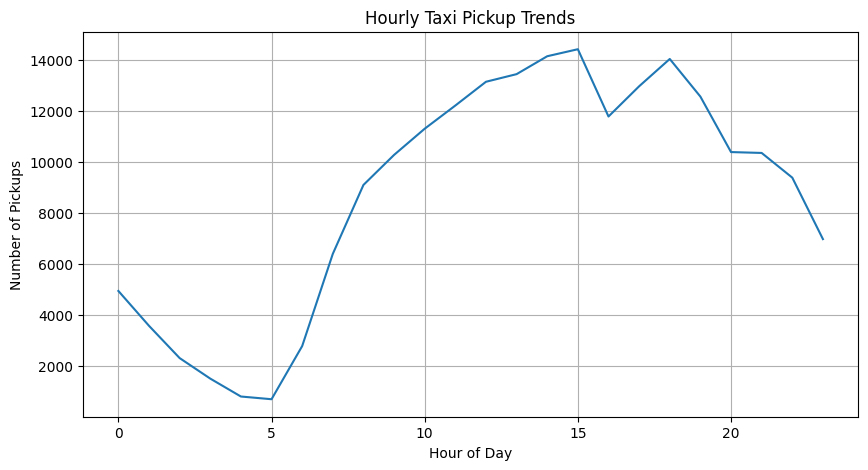

In [ ]:
import matplotlib.pyplot as plt

hourly_trends.plot(kind='line', figsize=(10,5))
plt.title("Hourly Taxi Pickup Trends")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.grid(True)
plt.show()


In [ ]:
# Convert pickup datetime to proper pandas datetime
sampled_data['tpep_pickup_datetime'] = pd.to_datetime(
    sampled_data['tpep_pickup_datetime'], errors='coerce'
)

# Extract day of week
sampled_data['day_of_week'] = sampled_data['tpep_pickup_datetime'].dt.dayofweek

# Compute daily trends
daily_trends = sampled_data.groupby('day_of_week').size()

# Map 0-6 to weekday names
day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
daily_trends.index = daily_trends.index.map(day_map)

print(daily_trends)

day_of_week
Mon    25367
Tue    30544
Wed    31895
Thu    32230
Fri    30427
Sat    32494
Sun    26605
dtype: int64


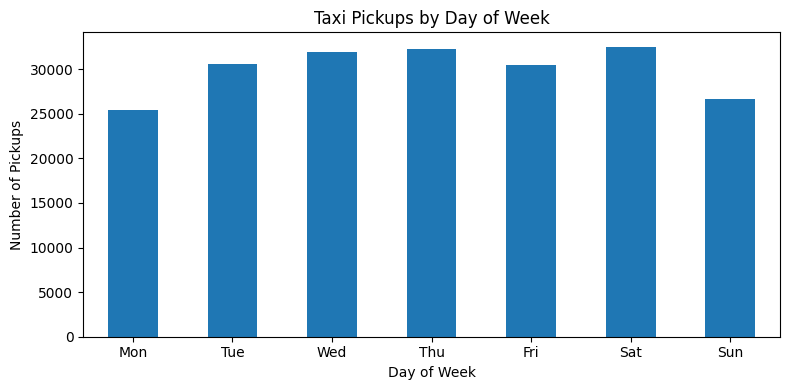

In [ ]:
plt.figure(figsize=(8,4))
daily_trends.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']).plot(kind='bar')
plt.title("Taxi Pickups by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Show the monthly trends in pickups


# Extract month number (1–12)
sampled_data['month'] = sampled_data['tpep_pickup_datetime'].dt.month

# Group by month
monthly_trends = sampled_data.groupby('month').size()

# Month name mapping
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

# Replace index numbers with month names
monthly_trends.index = monthly_trends.index.map(month_map)

print(monthly_trends)




month
Jan    17435
Feb    16523
Mar    18665
Apr    18233
May    19104
Jun    17963
Jul    15956
Aug    15317
Sep    15113
Oct    18881
Nov    18336
Dec    18036
dtype: int64


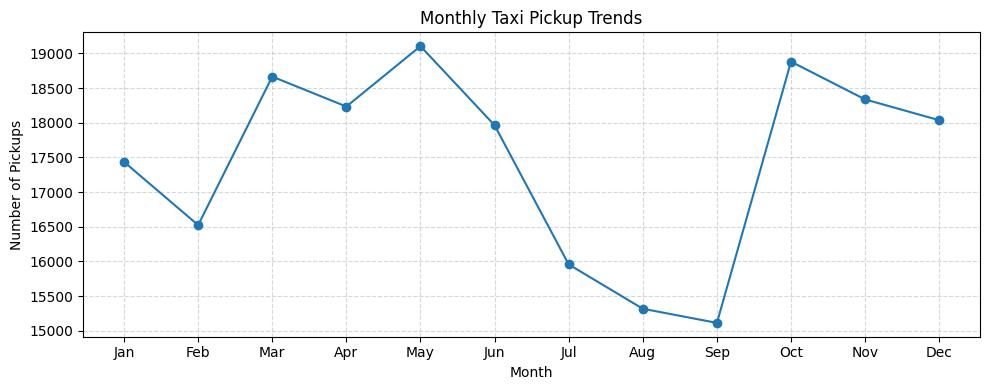

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(monthly_trends.index, monthly_trends.values, marker='o')
plt.title("Monthly Taxi Pickup Trends")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
#Checking for Negative values
cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols_to_check:
    neg_count = (sampled_data[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")


fare_amount: 0 negative values
tip_amount: 0 negative values
total_amount: 0 negative values
trip_distance: 0 negative values


In [ ]:
#Checking for 0 values
for col in cols_to_check:
    zero_count = (sampled_data[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

fare_amount: 26 zero values
tip_amount: 45552 zero values
total_amount: 0 zero values
trip_distance: 1938 zero values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

We can remove rows having 0 values for fare_amount, total_amount since all these need to be non-zero for a record to be considered as a trip.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.

sampled_data = sampled_data[
    ~(
        # Case 1: Distance is zero but pickup & dropoff are DIFFERENT zones → invalid
        ((sampled_data['trip_distance'] == 0) &
         (sampled_data['PULocationID'] != sampled_data['DOLocationID']))
        |
        # Case 2: Completely invalid ghost trip (no distance, no fare, no total)
        (
            (sampled_data['trip_distance'] == 0) &
            (sampled_data['fare_amount'] == 0) &
            (sampled_data['total_amount'] == 0)
        )
    )
]


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

month
1     337333.84
2     322514.53
3     366283.11
4     359184.66
5     382673.42
6     357760.96
7     313087.18
8     300812.75
9     304062.12
10    382957.00
11    371328.32
12    362196.67
Name: total_amount, dtype: float64


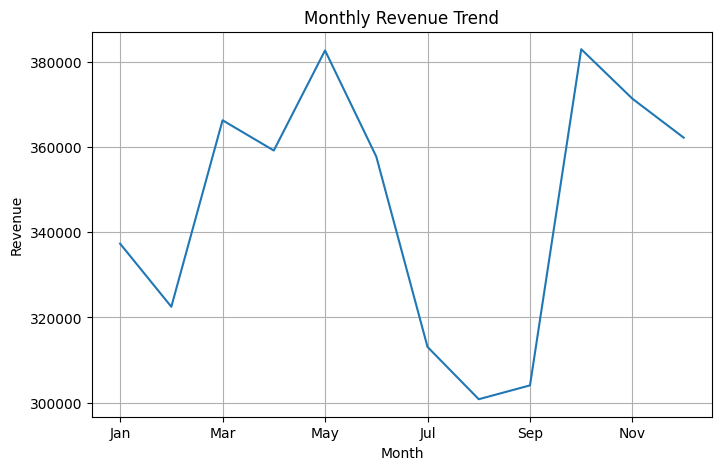

In [ ]:
# Group data by month and analyse monthly revenue

# Show the monthly trends in pickups
monthly_revenue = sampled_data.groupby('month').sum(numeric_only=True)['total_amount']
print(monthly_revenue)
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_revenue.index = monthly_revenue.index.map(month_map)

plt.figure(figsize=(8,5))
monthly_revenue.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter

# Extract quarter from the DateTimeIndex
sampled_data['quarter'] = sampled_data['tpep_pickup_datetime'].dt.quarter

# Calculate revenue (sum of total_amount) per quarter
quarter_revenue = sampled_data.groupby('quarter')['total_amount'].sum()

# Calculate the proportion of each quarter's revenue
quarter_revenue_proportion = (quarter_revenue / quarter_revenue.sum()) * 100


print(quarter_revenue_proportion)


quarter
1    24.665469
2    26.431914
3    22.065363
4    26.837254
Name: total_amount, dtype: float64


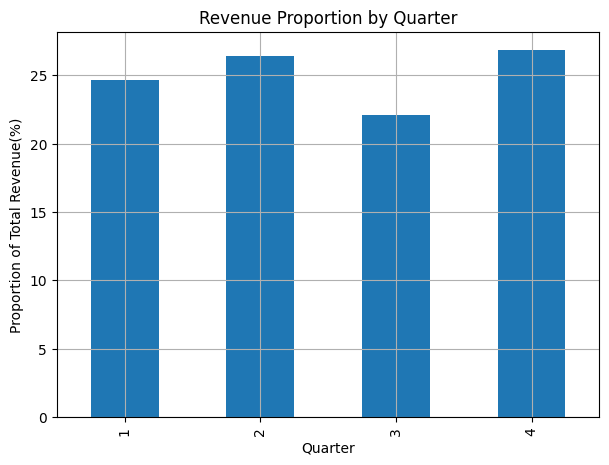

In [ ]:
quarter_revenue_proportion.plot(kind='bar', figsize=(7,5))
plt.title("Revenue Proportion by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Proportion of Total Revenue(%)")
plt.grid(True)
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [ ]:
# Show how trip fare is affected by distance

df_nonzero = sampled_data[sampled_data['trip_distance'] > 0]
correlation = df_nonzero['trip_distance'].corr(df_nonzero['fare_amount'])
print("Correlation:", correlation)

Correlation: 0.8646189558948523


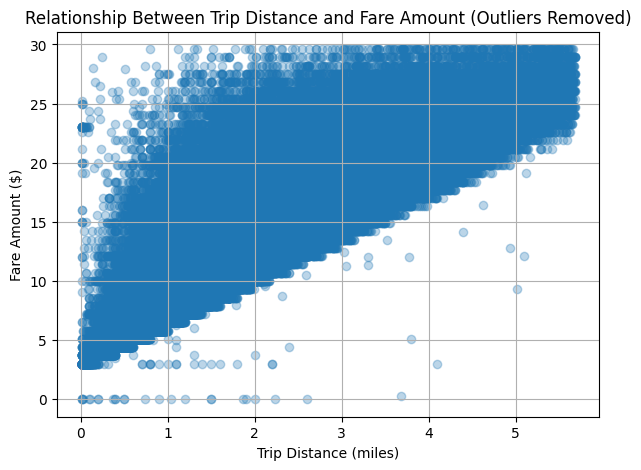

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df_nonzero['trip_distance'],
            df_nonzero['fare_amount'],
            alpha=0.3)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Relationship Between Trip Distance and Fare Amount (Outliers Removed)")
plt.grid(True)
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
# Ensure datetime columns are parsed properly
sampled_data['tpep_dropoff_datetime'] = pd.to_datetime(sampled_data['tpep_dropoff_datetime'], errors='coerce')

# Trip duration in minutes
sampled_data['trip_duration_min'] = (
    sampled_data['tpep_dropoff_datetime'] - sampled_data['tpep_pickup_datetime']
).dt.total_seconds() / 60


In [ ]:
sampled_data = sampled_data[sampled_data['trip_duration_min'] > 0]

In [ ]:
# Show relationship between fare and trip duration
corr_fare_duration = sampled_data['fare_amount'].corr(sampled_data['trip_duration_min'])
print("Correlation: fare_amount vs trip_duration:", corr_fare_duration)

Correlation: fare_amount vs trip_duration: 0.15521293132158934


In [ ]:
# Show relationship between fare and number of passengers
corr_fare_passenger = sampled_data['fare_amount'].corr(sampled_data['passenger_count'])
print("Correlation: fare_amount vs passenger_count:", corr_fare_passenger)


Correlation: fare_amount vs passenger_count: 0.02201691619567519


In [ ]:
# Show relationship between tip and trip distance
corr_tip_distance = sampled_data['tip_amount'].corr(sampled_data['trip_distance'])
print("Correlation: tip_amount vs trip_distance:", corr_tip_distance)

Correlation: tip_amount vs trip_distance: 0.3513674749040183


All the below combinations have very low correlation
- fare_amount and trip duration (pickup time to dropoff time)
- fare_amount and passenger_count
- tip_amount and trip_distance

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
# Analyse the distribution of different payment types (payment_type).

payment_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute'
}
# Map payment_type to readable names
sampled_data['payment_type_name'] = sampled_data['payment_type'].map(payment_map)

# Count each payment type
payment_counts = sampled_data['payment_type_name'].value_counts()

print(payment_counts)




payment_type_name
Credit Card    169480
Cash            37097
Dispute          1516
No Charge         785
Name: count, dtype: int64


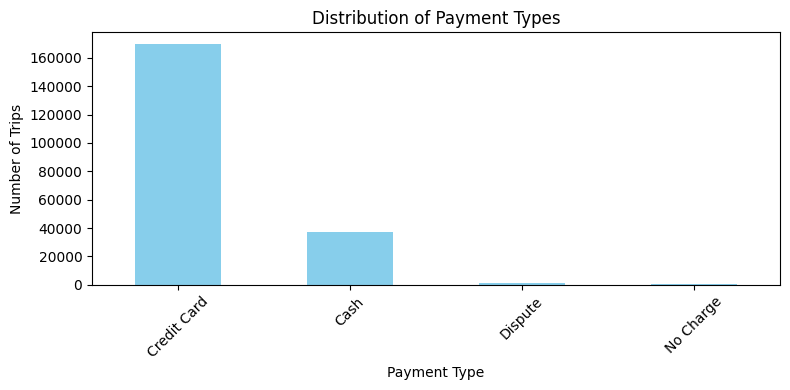

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
payment_counts.plot(kind='bar', color='skyblue')
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file("/content/drive/MyDrive/IIITB_EDA_Assignment/Datasets/taxi_zones/taxi_zones.shp")
zones.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

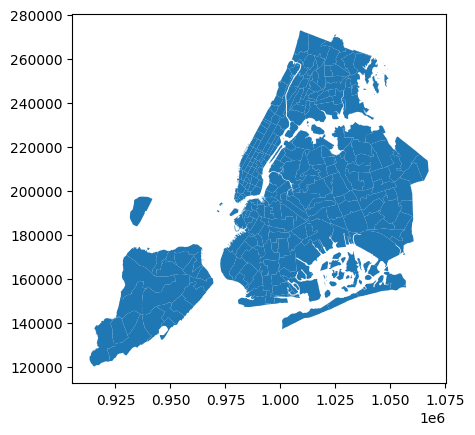

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
merged_pickup = sampled_data.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)



**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trips_by_pu = sampled_data.groupby('PULocationID').size().reset_index(name='total_pickups')
trips_by_pu.head()

,PULocationID,total_pickups
0,1,6
1,4,206
2,6,2
3,7,94
4,10,8


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame

zones_trips = zones.merge(trips_by_pu, left_on='LocationID', right_on='PULocationID', how='left')
zones_trips['total_pickups'] = zones_trips['total_pickups'].fillna(0)



The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

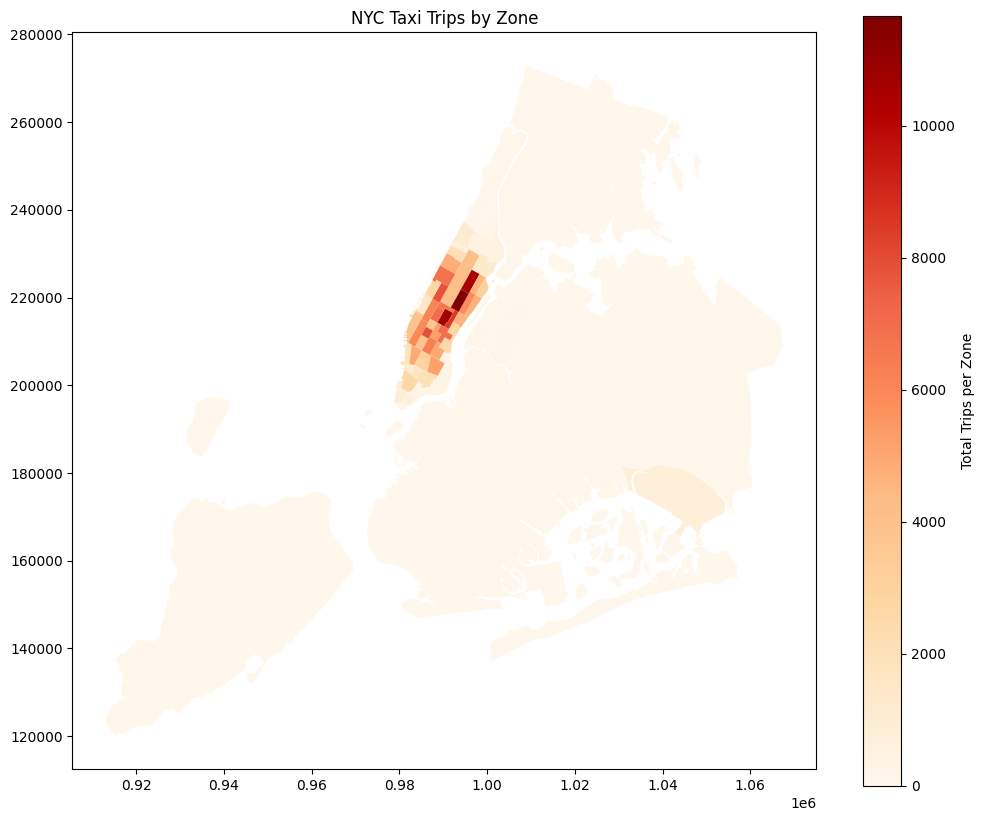

In [ ]:
import matplotlib.pyplot as plt

# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot choropleth
zones_trips.plot(
    column='total_pickups',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Total Trips per Zone",
        'orientation': "vertical"
    },
    cmap='OrRd'
)

plt.title("NYC Taxi Trips by Zone")
plt.show()



In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
zones_trips_sorted = zones_trips.sort_values('total_pickups', ascending=False)

zones_trips_sorted

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,total_pickups
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,11666.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,10585.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,10444.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,8442.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",186.0,7869.0
...,...,...,...,...,...,...,...,...,...
130,131,0.116547,0.000424,Jamaica Estates,131,Queens,"POLYGON ((1045972.529 202542.128, 1045985.752 ...",NaN,0.0
125,126,0.129949,0.000703,Hunts Point,126,Bronx,"POLYGON ((1015758.026 240707.476, 1015703.302 ...",NaN,0.0
123,124,0.127724,0.000755,Howard Beach,124,Queens,"MULTIPOLYGON (((1025592.187 184037.103, 102628...",NaN,0.0
122,123,0.083421,0.000296,Homecrest,123,Brooklyn,"POLYGON ((994561.79 162446.868, 994695.533 161...",NaN,0.0


In [ ]:
sampled_data.to_csv('/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data_cleaned_2.csv', index=False)
print("Cleaned DataFrame saved successfully to Google Drive!")

Cleaned DataFrame saved successfully to Google Drive!


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
cleaned_data = pd.read_csv("/content/drive/MyDrive/IIITB_EDA_Assignment/NYC_sampled_data_cleaned_2.csv")

In [ ]:
# Convert datetime columns
cleaned_data['tpep_pickup_datetime'] = pd.to_datetime(cleaned_data['tpep_pickup_datetime'])
cleaned_data['tpep_dropoff_datetime'] = pd.to_datetime(cleaned_data['tpep_dropoff_datetime'])

In [ ]:
# Find routes which have the slowest speeds at different times of the day
# Trip duration (in hours)
cleaned_data['trip_duration_hr'] = (
    cleaned_data['tpep_dropoff_datetime'] - cleaned_data['tpep_pickup_datetime']
).dt.total_seconds() / 3600

# Filter invalid trips
cleaned_data = cleaned_data[(cleaned_data['trip_duration_hr'] > 0) & (cleaned_data['trip_distance'] > 0)]

# Speed in mph
cleaned_data['speed_mph'] = cleaned_data['trip_distance'] / cleaned_data['trip_duration_hr']

In [ ]:
route_speeds = (
    cleaned_data.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['speed_mph']
    .mean()
    .reset_index()
)

In [ ]:
route_speeds.sort_values('speed_mph').groupby('pickup_hour').head(5)      # top 5 slowest routes per hour



,PULocationID,DOLocationID,pickup_hour,speed_mph
38941,260,129,17,0.040746
27727,209,232,13,0.043579
3647,50,43,8,0.059525
7936,88,144,0,0.074923
26342,181,132,20,0.091611
...,...,...,...,...
15775,141,162,4,5.286713
25375,170,68,3,5.308204
23418,163,163,3,5.318476
29563,229,237,4,5.320197


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = cleaned_data.groupby('pickup_hour').size()
busiest_hour = trips_per_hour.idxmax()
busiest_count = trips_per_hour.max()

print("Busiest Hour:", busiest_hour)
print("Number of Trips:", busiest_count)

Busiest Hour: 15
Number of Trips: 14275


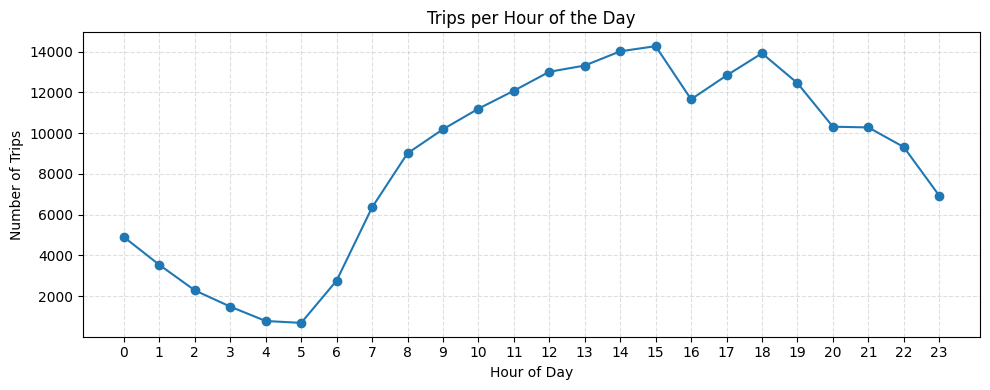

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(trips_per_hour.index, trips_per_hour.values, marker='o')
plt.title("Trips per Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

In [ ]:
scale_factor = 1 / 0.008 #Since we took a sample of 0.8%
actual_trips_per_hour = trips_per_hour * scale_factor
busiest_hour = actual_trips_per_hour.idxmax()
busiest_count = actual_trips_per_hour.max()

print("Busiest Hour:", busiest_hour)
print("Estimated Actual Trips:", int(busiest_count))


Busiest Hour: 15
Estimated Actual Trips: 1784375


**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

actual_trips_per_hour.sort_values(ascending=False).head(5)


,0
pickup_hour,
15,1784375.0
14,1752750.0
18,1740625.0
13,1665500.0
12,1627000.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

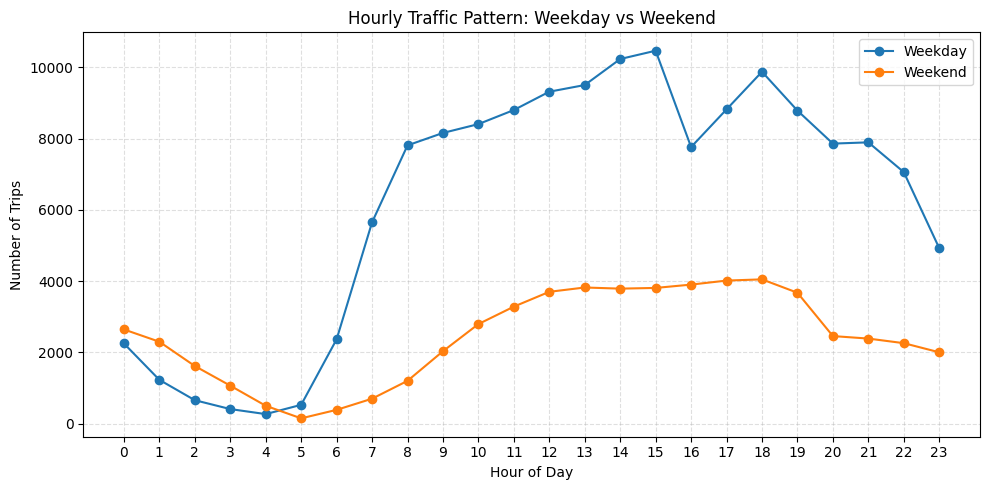

In [ ]:
# Compare traffic trends for the week days and weekends
cleaned_data['day_type'] = cleaned_data['day_of_week'].apply(
    lambda x: 'Weekday' if x < 5 else 'Weekend'
)
hourly_pattern = cleaned_data.groupby(['pickup_hour', 'day_type']).size().reset_index(name='trips')
hourly_pivot = hourly_pattern.pivot(index='pickup_hour', columns='day_type', values='trips') #for easy plotting


#Plotting the trends for clear visualization
plt.figure(figsize=(10, 5))
plt.plot(hourly_pivot.index, hourly_pivot['Weekday'], marker='o', label='Weekday')
plt.plot(hourly_pivot.index, hourly_pivot['Weekend'], marker='o', label='Weekend')

plt.title("Hourly Traffic Pattern: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
import geopandas as gpd
zones = gpd.read_file("/content/drive/MyDrive/IIITB_EDA_Assignment/Datasets/taxi_zones/taxi_zones.shp")
zones.head() #Load the zone data to get the zone names

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
# Find top 10 pickup and dropoff zones
top10_pickups = (
    cleaned_data.groupby('PULocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='total_pickups')
)

top10_dropoffs = (
    cleaned_data.groupby('DOLocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='total_dropoffs')
)

top10_pickups = top10_pickups.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

top10_dropoffs = top10_dropoffs.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])



In [ ]:
print("Top 10 Pickup Zones:")
display(top10_pickups)

print("Top 10 Dropoff Zones:")
display(top10_dropoffs)


Top 10 Pickup Zones:


,PULocationID,total_pickups,zone
0,237,11641,Upper East Side South
1,161,10567,Midtown Center
2,236,10425,Upper East Side North
3,162,8421,Midtown East
4,186,7851,Penn Station/Madison Sq West
5,142,7773,Lincoln Square East
6,230,7039,Times Sq/Theatre District
7,170,6929,Murray Hill
8,239,6797,Upper West Side South
9,163,6609,Midtown North


Top 10 Dropoff Zones:


,DOLocationID,total_dropoffs,zone
0,236,10853,Upper East Side North
1,237,10442,Upper East Side South
2,161,9523,Midtown Center
3,170,6920,Murray Hill
4,142,6816,Lincoln Square East
5,162,6798,Midtown East
6,239,6368,Upper West Side South
7,230,6271,Times Sq/Theatre District
8,141,6129,Lenox Hill West
9,68,5949,East Chelsea


In [ ]:
#Hourly trends for Pickup and drop off zones
pickup_counts = (
    cleaned_data.groupby(['PULocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trips')
)
dropoff_counts = (
    cleaned_data.groupby(['DOLocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trips')
)

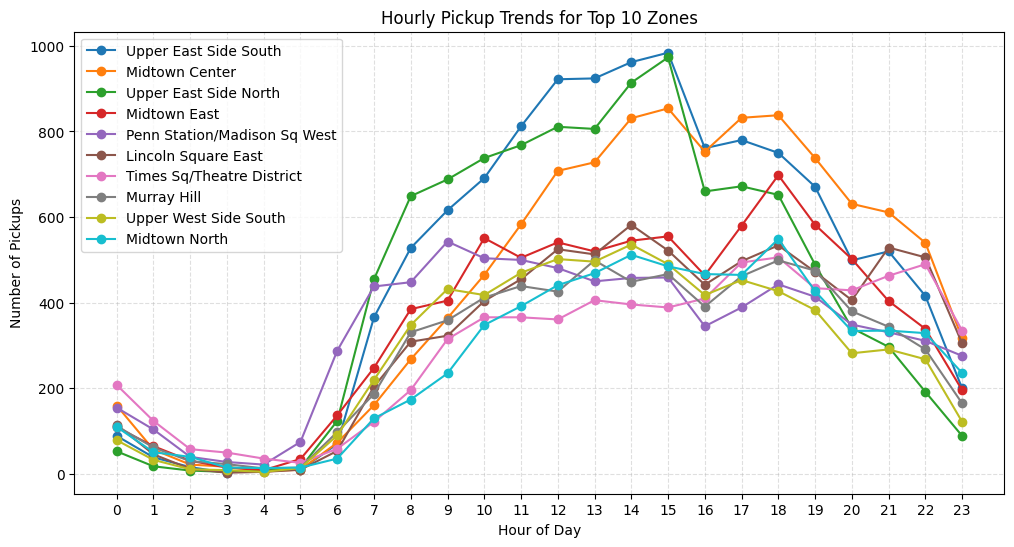

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for zone_id in top10_pickups['PULocationID']:
    subset = pickup_counts[pickup_counts['PULocationID'] == zone_id]
    zone_name = zones.loc[zones['LocationID'] == zone_id, 'zone'].values[0]
    plt.plot(subset['pickup_hour'], subset['trips'], marker='o', label=zone_name)

plt.title("Hourly Pickup Trends for Top 10 Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()


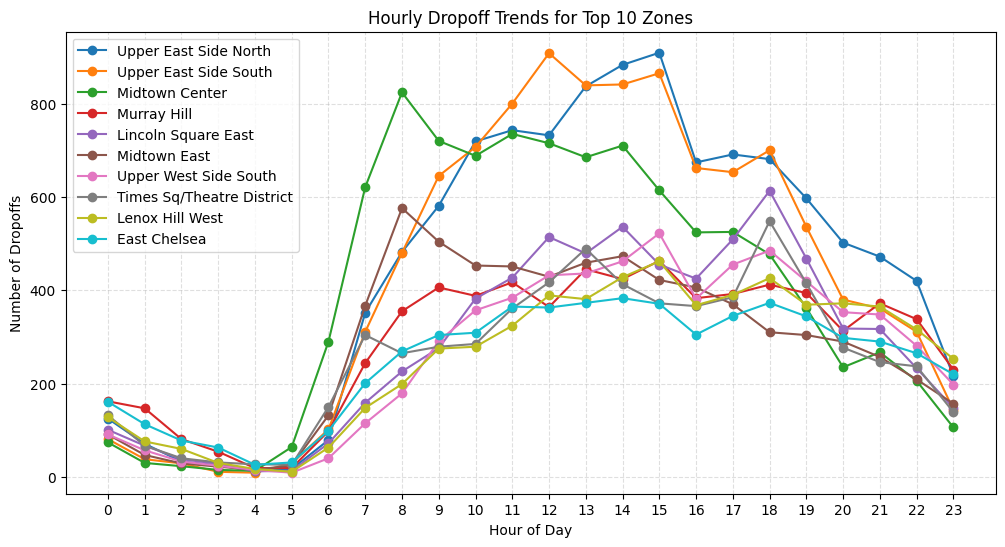

In [ ]:
plt.figure(figsize=(12, 6))

for zone_id in top10_dropoffs['DOLocationID']:
    subset = dropoff_counts[dropoff_counts['DOLocationID'] == zone_id]
    zone_name = zones.loc[zones['LocationID'] == zone_id, 'zone'].values[0]
    plt.plot(subset['pickup_hour'], subset['trips'], marker='o', label=zone_name)

plt.title("Hourly Dropoff Trends for Top 10 Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Dropoffs")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = (
    cleaned_data.groupby('PULocationID')
    .size()
    .reset_index(name='pickups')
)
dropoff_counts = (
    cleaned_data.groupby('DOLocationID')
    .size()
    .reset_index(name='dropoffs')
)
zone_flow = pickup_counts.merge(
    dropoff_counts,
    left_on='PULocationID',
    right_on='DOLocationID',
    how='outer'
)
zone_flow['LocationID'] = zone_flow['PULocationID'].fillna(zone_flow['DOLocationID'])
zone_flow = zone_flow[['LocationID', 'pickups', 'dropoffs']]
zone_flow = zone_flow.fillna(0)

In [ ]:
zone_flow['ratio'] = zone_flow['pickups'] / zone_flow['dropoffs'].replace(0, 1)
zone_flow = zone_flow.merge(
    zones[['LocationID', 'zone']],
    on='LocationID',
    how='left'
)


In [ ]:
top10_highest = zone_flow.sort_values('ratio', ascending=False).head(10)
print("Top 10 Pickup/Dropoff Ratios:")
display(top10_highest[['LocationID','zone','pickups','dropoffs','ratio']])


Top 10 Pickup/Dropoff Ratios:


,LocationID,zone,pickups,dropoffs,ratio
96,132.0,JFK Airport,762.0,193.0,3.948187
52,70.0,East Elmhurst,53.0,16.0,3.312500
57,76.0,East New York,3.0,1.0,3.000000
139,182.0,Parkchester,3.0,0.0,3.000000
134,175.0,Oakland Gardens,3.0,1.0,3.000000
19,29.0,Brighton Beach,2.0,0.0,2.000000
43,60.0,Crotona Park East,2.0,1.0,2.000000
72,95.0,Forest Hills,17.0,11.0,1.545455
140,186.0,Penn Station/Madison Sq West,7851.0,5318.0,1.476307
201,261.0,World Trade Center,991.0,681.0,1.455213


In [ ]:
top10_lowest = zone_flow.sort_values('ratio', ascending=True).head(10)
print("Bottom 10 Pickup/Dropoff Ratios:")
display(top10_lowest[['LocationID','zone','pickups','dropoffs','ratio']])


Bottom 10 Pickup/Dropoff Ratios:


,LocationID,zone,pickups,dropoffs,ratio
77,102.0,Glendale,0.0,2.0,0.0
23,35.0,Brownsville,0.0,3.0,0.0
99,135.0,Kew Gardens Hills,0.0,2.0,0.0
26,38.0,Cambria Heights,0.0,1.0,0.0
198,257.0,Windsor Terrace,0.0,7.0,0.0
95,131.0,Jamaica Estates,0.0,3.0,0.0
90,126.0,Hunts Point,0.0,1.0,0.0
88,124.0,Howard Beach,0.0,12.0,0.0
87,122.0,Hollis,0.0,1.0,0.0
100,136.0,Kingsbridge Heights,0.0,3.0,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_data = cleaned_data[
    (cleaned_data['pickup_hour'] >= 23) | (cleaned_data['pickup_hour'] <= 5)
]
night_pickups = (
    night_data.groupby('PULocationID')
    .size()
    .reset_index(name='night_pickups')
    .sort_values('night_pickups', ascending=False)
    .head(10)
)
night_dropoffs = (
    night_data.groupby('DOLocationID')
    .size()
    .reset_index(name='night_dropoffs')
    .sort_values('night_dropoffs', ascending=False)
    .head(10)
)


In [ ]:
night_pickups = night_pickups.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

night_dropoffs = night_dropoffs.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])


In [ ]:
print("Top 10 Night-Time Pickup Zones (11PM–5AM):")
display(night_pickups[['PULocationID','zone','night_pickups']])

print("Top 10 Night-Time Dropoff Zones (11PM–5AM):")
display(night_dropoffs[['DOLocationID','zone','night_dropoffs']])


Top 10 Night-Time Pickup Zones (11PM–5AM):


,PULocationID,zone,night_pickups
0,79,East Village,1681
1,249,West Village,1371
2,48,Clinton East,1084
3,148,Lower East Side,1040
4,114,Greenwich Village South,969
5,230,Times Sq/Theatre District,837
6,186,Penn Station/Madison Sq West,700
7,164,Midtown South,670
8,107,Gramercy,647
9,68,East Chelsea,612


Top 10 Night-Time Dropoff Zones (11PM–5AM):


,DOLocationID,zone,night_dropoffs
0,79,East Village,1011
1,48,Clinton East,805
2,170,Murray Hill,712
3,68,East Chelsea,692
4,107,Gramercy,666
5,141,Lenox Hill West,575
6,249,West Village,565
7,263,Yorkville West,548
8,90,Flatiron,510
9,236,Upper East Side North,499


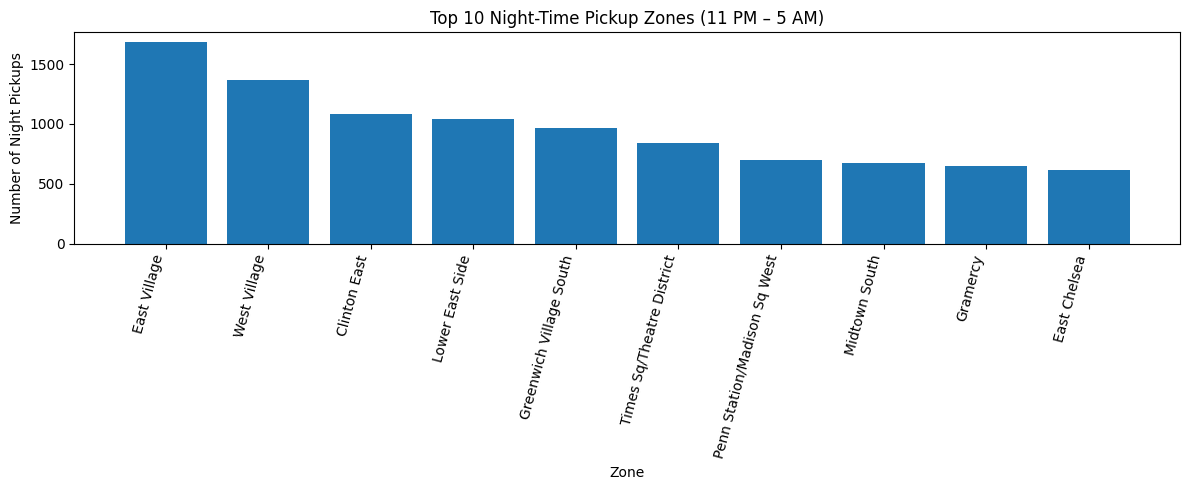

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(night_pickups['zone'], night_pickups['night_pickups'])
plt.xticks(rotation=75, ha='right')
plt.title("Top 10 Night-Time Pickup Zones (11 PM – 5 AM)")
plt.xlabel("Zone")
plt.ylabel("Number of Night Pickups")
plt.tight_layout()
plt.show()


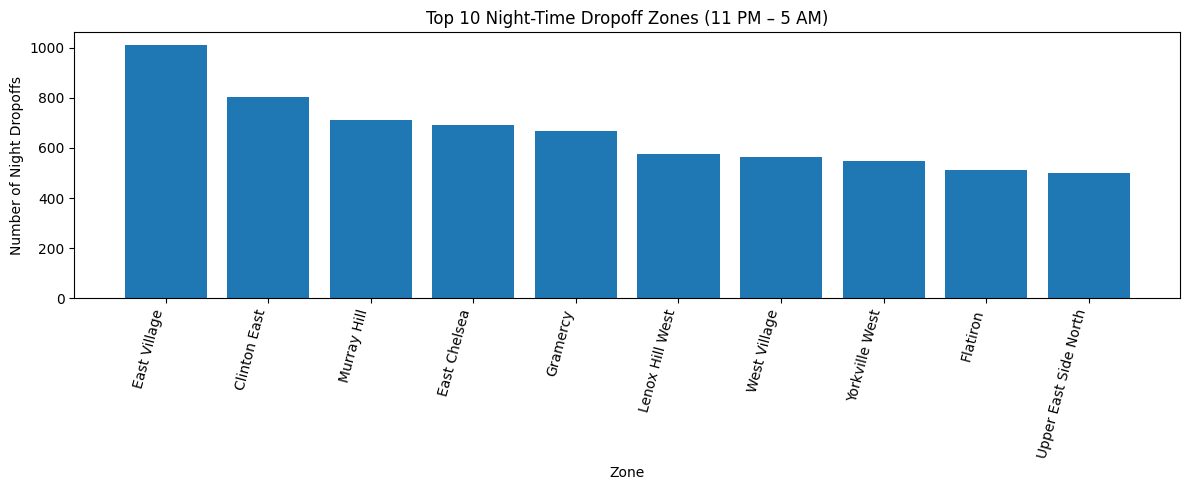

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(night_dropoffs['zone'], night_dropoffs['night_dropoffs'])
plt.xticks(rotation=75, ha='right')
plt.title("Top 10 Night-Time Dropoff Zones (11 PM – 5 AM)")
plt.xlabel("Zone")
plt.ylabel("Number of Night Dropoffs")
plt.tight_layout()
plt.show()


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)

day_data   = cleaned_data[(cleaned_data['pickup_hour'] >= 6) & (cleaned_data['pickup_hour'] <= 22)]
night_data = cleaned_data[(cleaned_data['pickup_hour'] >= 23) | (cleaned_data['pickup_hour'] <= 5)]
night_revenue = night_data['total_amount'].sum()
day_revenue   = day_data['total_amount'].sum()
total_revenue = night_revenue + day_revenue


Night Revenue Share (11 PM – 5 AM): 10.04 %
Day   Revenue Share (6 AM – 10 PM): 89.96 %


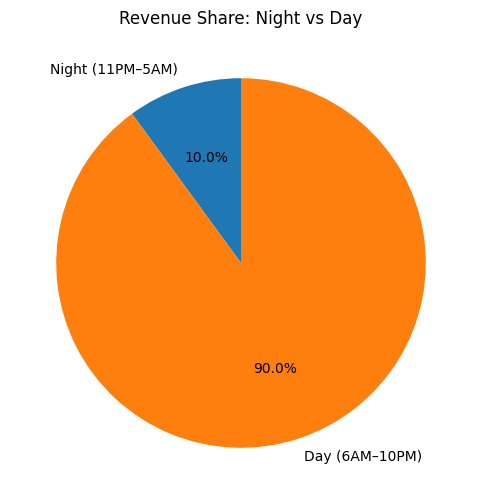

In [ ]:
night_share = (night_revenue / total_revenue) * 100
day_share   = (day_revenue / total_revenue) * 100

print("Night Revenue Share (11 PM – 5 AM):", round(night_share, 2), "%")
print("Day   Revenue Share (6 AM – 10 PM):", round(day_share, 2), "%")


plt.figure(figsize=(6,6))
plt.pie(
    [night_revenue, day_revenue],
    labels=['Night (11PM–5AM)', 'Day (6AM–10PM)'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Revenue Share: Night vs Day")
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

# Filter invalid values
valid = cleaned_data[
    (cleaned_data['trip_distance'] > 0) &
    (cleaned_data['passenger_count'] > 0) &
    (cleaned_data['fare_amount'] > 0)
].copy()

# Compute metric
valid['fare_per_mile_per_passenger'] = (
    valid['fare_amount'] / (valid['trip_distance'] * valid['passenger_count'])
)


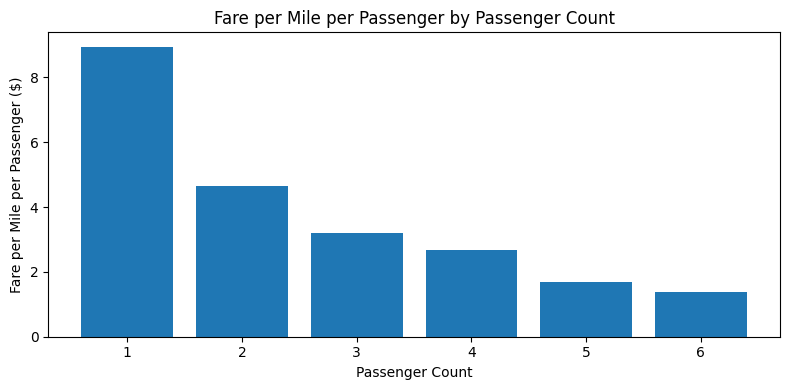

In [ ]:
analysis = (
    valid.groupby('passenger_count')['fare_per_mile_per_passenger']
    .mean()
    .reset_index()
    .sort_values('passenger_count')
)



plt.figure(figsize=(8,4))
plt.bar(analysis['passenger_count'], analysis['fare_per_mile_per_passenger'])
plt.title("Fare per Mile per Passenger by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare per Mile per Passenger ($)")
plt.tight_layout()
plt.show()



**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
# Compute fare per mile
valid['fare_per_mile'] = valid['fare_amount'] / valid['trip_distance']

fare_per_mile_hour = (
    valid.groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index()
)

fare_per_mile_dow = (
    valid.groupby('day_of_week')['fare_per_mile']
    .mean()
    .reset_index()
)

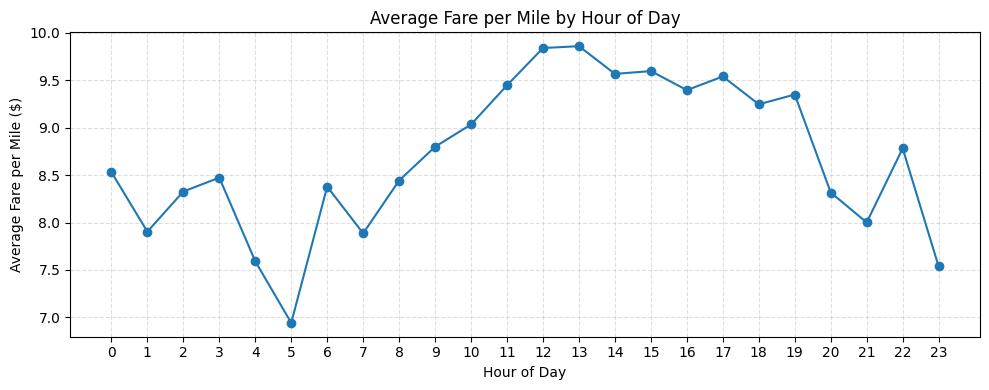

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(fare_per_mile_hour['pickup_hour'], fare_per_mile_hour['fare_per_mile'], marker='o')
plt.title("Average Fare per Mile by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile ($)")
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


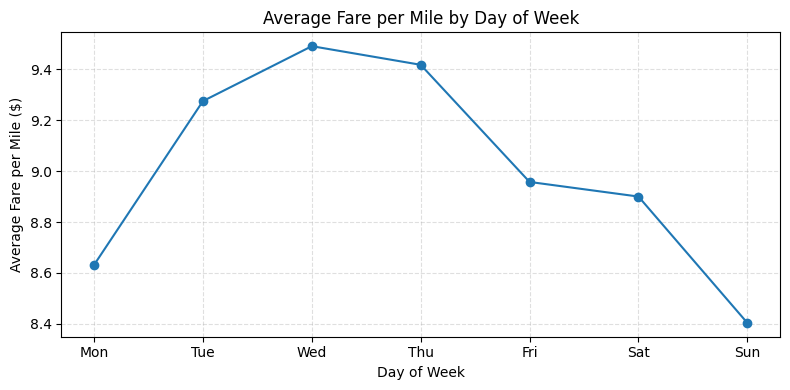

In [ ]:
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,4))
plt.plot(fare_per_mile_dow['day_of_week'], fare_per_mile_dow['fare_per_mile'], marker='o')
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Fare per Mile ($)")
plt.xticks(range(7), dow_labels)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

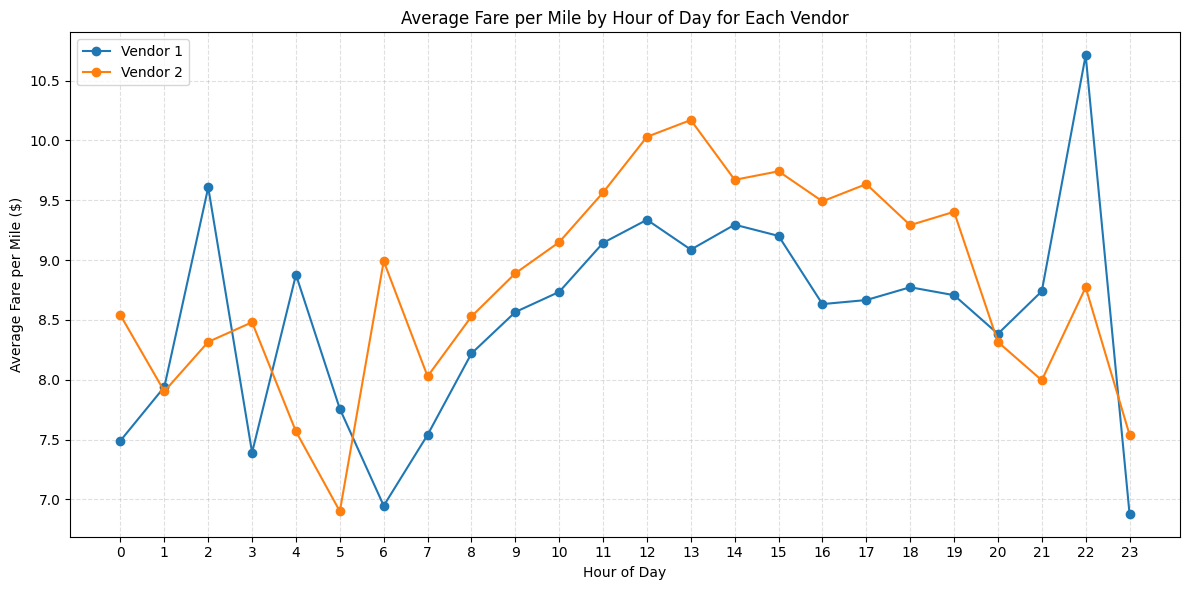

In [ ]:
# Compare fare per mile for different vendors
vendor_hour_fare = (
    valid.groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for vendor in vendor_hour_fare['VendorID'].unique():
    subset = vendor_hour_fare[vendor_hour_fare['VendorID'] == vendor]
    plt.plot(subset['pickup_hour'], subset['fare_per_mile'], marker='o', label=f"Vendor {vendor}")

plt.title("Average Fare per Mile by Hour of Day for Each Vendor")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile ($)")
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers
def distance_tier(d):
    if d <= 2:
        return "0–2 miles"
    elif d <= 5:
        return "2–5 miles"
    else:
        return "5+ miles"

valid['tier'] = valid['trip_distance'].apply(distance_tier)
vendor_tier_fares = (
    valid.groupby(['VendorID', 'tier'])['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values(['tier', 'VendorID'])
)

print(vendor_tier_fares)



   VendorID       tier  fare_per_mile
0         1  0–2 miles       9.748614
3         2  0–2 miles      10.410126
1         1  2–5 miles       6.464431
4         2  2–5 miles       6.409901
2         1   5+ miles       4.805694
5         2   5+ miles       4.822892


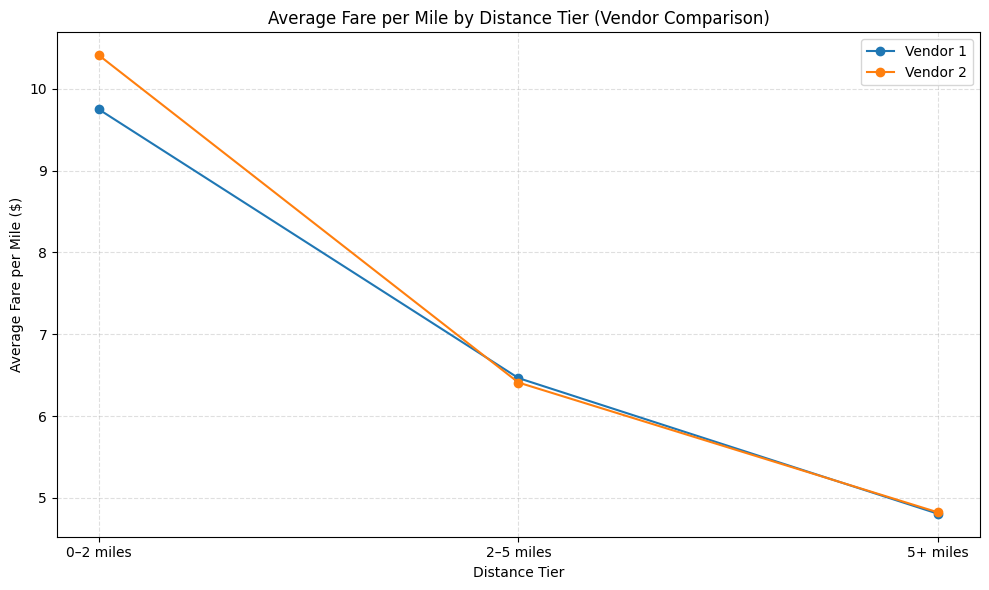

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for vendor in vendor_tier_fares['VendorID'].unique():
    subset = vendor_tier_fares[vendor_tier_fares['VendorID'] == vendor]
    plt.plot(subset['tier'], subset['fare_per_mile'], marker='o', label=f"Vendor {vendor}")

plt.title("Average Fare per Mile by Distance Tier (Vendor Comparison)")
plt.xlabel("Distance Tier")
plt.ylabel("Average Fare per Mile ($)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
valid = cleaned_data[
    (cleaned_data['fare_amount'] > 0) &
    (cleaned_data['tip_amount'] >= 0)
].copy()

valid['tip_percent'] = (valid['tip_amount'] / valid['fare_amount']) * 100



  distance_bin  tip_percent
0     0–1 mile    23.765907
1    1–3 miles    20.400968
2    3–7 miles    17.017696


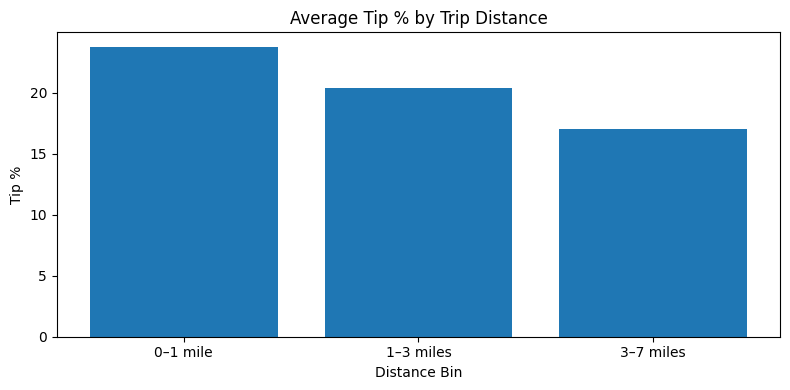

In [ ]:
def distance_bin(d):
    if d <= 1: return "0–1 mile"
    elif d <= 3: return "1–3 miles"
    elif d <= 7: return "3–7 miles"
    else: return "7+ miles"

valid['distance_bin'] = valid['trip_distance'].apply(distance_bin)

tip_by_distance = (
    valid.groupby('distance_bin')['tip_percent']
    .mean()
    .reset_index()
    .sort_values('distance_bin')
)

print(tip_by_distance)


plt.figure(figsize=(8,4))
plt.bar(tip_by_distance['distance_bin'], tip_by_distance['tip_percent'])
plt.title("Average Tip % by Trip Distance")
plt.ylabel("Tip %")
plt.xlabel("Distance Bin")
plt.tight_layout()
plt.show()


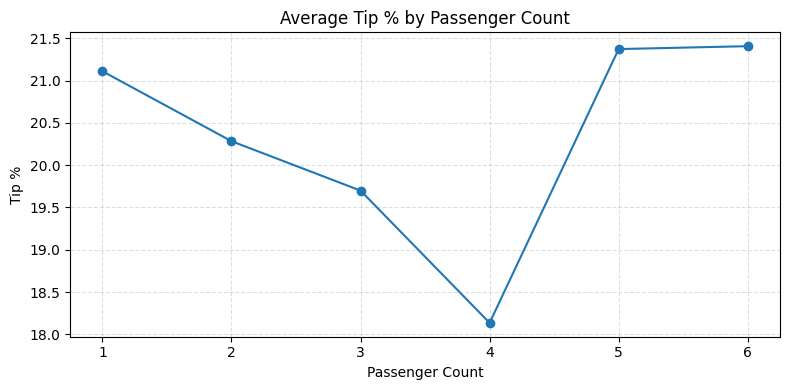

In [ ]:
tip_by_passengers = (
    valid.groupby('passenger_count')['tip_percent']
    .mean()
    .reset_index()
    .sort_values('passenger_count')
)

plt.figure(figsize=(8,4))
plt.plot(tip_by_passengers['passenger_count'], tip_by_passengers['tip_percent'], marker='o')
plt.title("Average Tip % by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Tip %")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



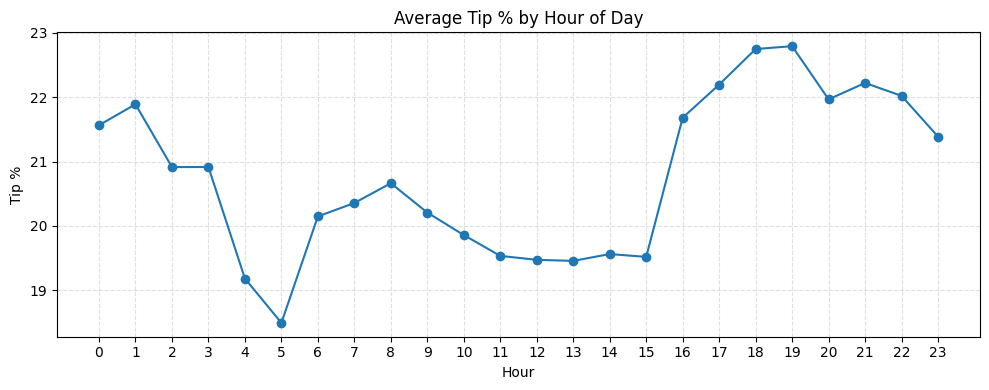

In [ ]:
valid['pickup_hour'] = valid['tpep_pickup_datetime'].dt.hour

tip_by_hour = (
    valid.groupby('pickup_hour')['tip_percent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(tip_by_hour['pickup_hour'], tip_by_hour['tip_percent'], marker='o')
plt.title("Average Tip % by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Tip %")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Trip duration in minutes
valid['trip_duration_min'] = (
    valid['tpep_dropoff_datetime'] - valid['tpep_pickup_datetime']
).dt.total_seconds() / 60

low_tip = valid[valid['tip_percent'] < 10]
high_tip = valid[valid['tip_percent'] > 25]

comparison = pd.DataFrame({
    "Metric": [
        "Average Fare ($)",
        "Average Trip Distance (miles)",
        "Average Trip Duration (min)",
        "Average Passenger Count",
        "Average Fare per Mile ($)"
    ],
    "Tip < 10%": [
        low_tip['fare_amount'].mean(),
        low_tip['trip_distance'].mean(),
        low_tip['trip_duration_min'].mean(),
        low_tip['passenger_count'].mean(),
        (low_tip['fare_amount'] / low_tip['trip_distance']).mean()
    ],
    "Tip > 25%": [
        high_tip['fare_amount'].mean(),
        high_tip['trip_distance'].mean(),
        high_tip['trip_duration_min'].mean(),
        high_tip['passenger_count'].mean(),
        (high_tip['fare_amount'] / high_tip['trip_distance']).mean()
    ]
})

print(comparison)



                          Metric  Tip < 10%  Tip > 25%
0               Average Fare ($)  13.173660  11.208391
1  Average Trip Distance (miles)   1.781344   1.485932
2    Average Trip Duration (min)  14.902681  10.474130
3        Average Passenger Count   1.421008   1.370786
4      Average Fare per Mile ($)  10.542828   8.681418


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

    pickup_hour  passenger_count
0             0         1.443537
1             1         1.462758
2             2         1.468188
3             3         1.467884
4             4         1.368217
5             5         1.280470
6             6         1.196590
7             7         1.255668
8             8         1.277852
9             9         1.301609
10           10         1.346545
11           11         1.348751
12           12         1.360403
13           13         1.347118
14           14         1.372771
15           15         1.396708
16           16         1.420746
17           17         1.393300
18           18         1.393465
19           19         1.419101
20           20         1.412289
21           21         1.448507
22           22         1.463140
23           23         1.495527


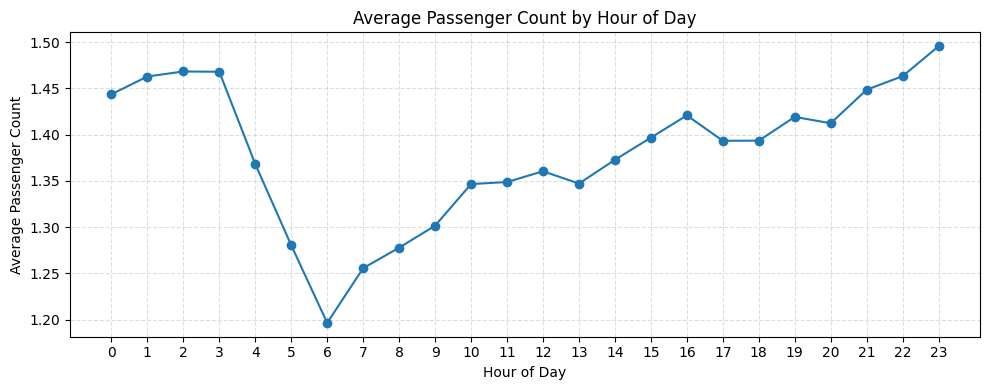

In [ ]:
# See how passenger count varies across hours and days
passengers_by_hour = (
    cleaned_data.groupby('pickup_hour')['passenger_count']
    .mean()
    .reset_index()
)

print(passengers_by_hour)

plt.figure(figsize=(10,4))
plt.plot(passengers_by_hour['pickup_hour'], passengers_by_hour['passenger_count'], marker='o')
plt.title("Average Passenger Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Passenger Count")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

   day_of_week  passenger_count
0            0         1.353565
1            1         1.327819
2            2         1.327338
3            3         1.336610
4            4         1.396014
5            5         1.474530
6            6         1.464795


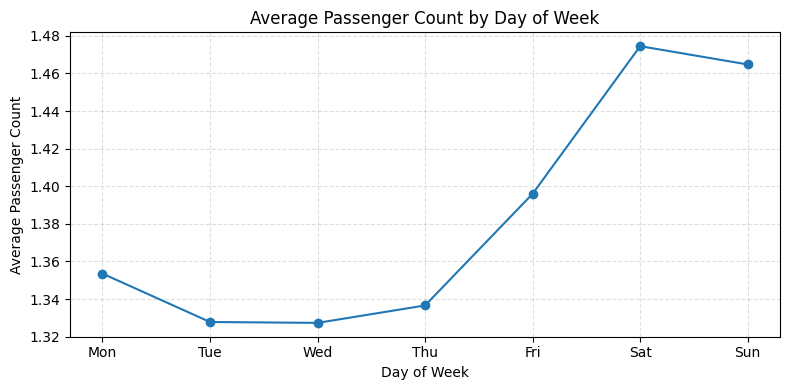

In [ ]:
passengers_by_dow = (
    cleaned_data.groupby('day_of_week')['passenger_count']
    .mean()
    .reset_index()
)

print(passengers_by_dow)
plt.figure(figsize=(8,4))
plt.plot(passengers_by_dow['day_of_week'], passengers_by_dow['passenger_count'], marker='o')
plt.title("Average Passenger Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Passenger Count")
plt.xticks(range(7), dow_labels)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones
passenger_zone = (
    cleaned_data.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index()
    .rename(columns={
        'PULocationID': 'LocationID',
        'passenger_count': 'avg_passenger_count'
    })
)
passenger_zone.sort_values('avg_passenger_count', ascending=False).head(10)



,LocationID,avg_passenger_count
115,191,3.000000
26,47,2.666667
134,219,2.666667
42,69,2.500000
7,14,2.333333
50,82,2.142857
118,195,2.000000
70,127,2.000000
103,171,2.000000
105,174,2.000000


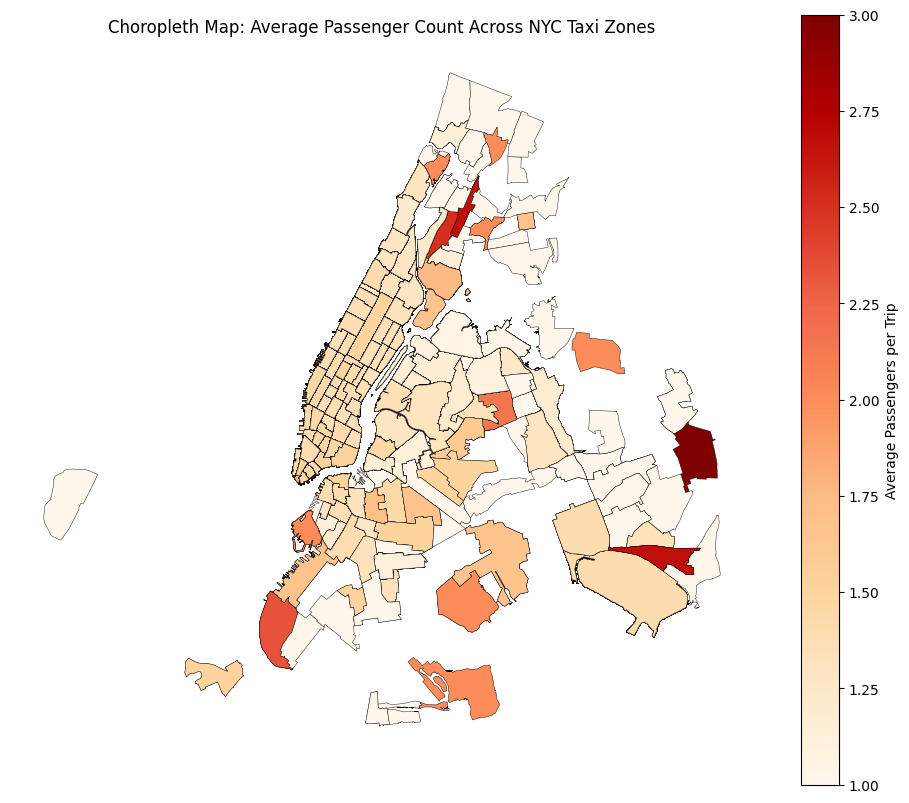

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_trips = zones.merge(cleaned_data, left_on='LocationID', right_on='PULocationID', how='left')
zones_trips['avg_passenger_count'] = zones_trips['LocationID'].map(
    cleaned_data.groupby('PULocationID')['passenger_count'].mean()
)


import matplotlib.pyplot as plt

# Create figure + axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))


zones_trips.plot(
    column='avg_passenger_count',
    ax=ax,
    cmap='OrRd',
    legend=True,
    legend_kwds={
        'label': "Average Passengers per Trip",
        'orientation': "vertical"
    },
    edgecolor='black',
    linewidth=0.3
)

ax.set_title("Choropleth Map: Average Passenger Count Across NYC Taxi Zones")
ax.axis("off")

plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?
extra_data = cleaned_data[cleaned_data['extra'] > 0].copy()
#Top 10 Pickup Zones with the most extra charges
extra_pu = (
    extra_data.groupby('PULocationID').size()
    .reset_index(name='extra_count')
    .sort_values('extra_count', ascending=False)
)

extra_pu = extra_pu.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID', right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

extra_pu.head(10)



,PULocationID,extra_count,zone
0,161,6227,Midtown Center
1,237,6019,Upper East Side South
2,236,4974,Upper East Side North
3,162,4752,Midtown East
4,142,4444,Lincoln Square East
5,230,4420,Times Sq/Theatre District
6,186,4258,Penn Station/Madison Sq West
7,163,3828,Midtown North
8,170,3814,Murray Hill
9,234,3767,Union Sq


In [ ]:
#Top 10 Dropoff Zones with the most extra charges

extra_do = (
    extra_data.groupby('DOLocationID').size()
    .reset_index(name='extra_count')
    .sort_values('extra_count', ascending=False)
)

extra_do = extra_do.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID', right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

extra_do.head(10)


,DOLocationID,extra_count,zone
0,236,5766,Upper East Side North
1,237,5209,Upper East Side South
2,161,4304,Midtown Center
3,170,3959,Murray Hill
4,142,3776,Lincoln Square East
5,141,3660,Lenox Hill West
6,239,3649,Upper West Side South
7,48,3387,Clinton East
8,230,3380,Times Sq/Theatre District
9,68,3350,East Chelsea


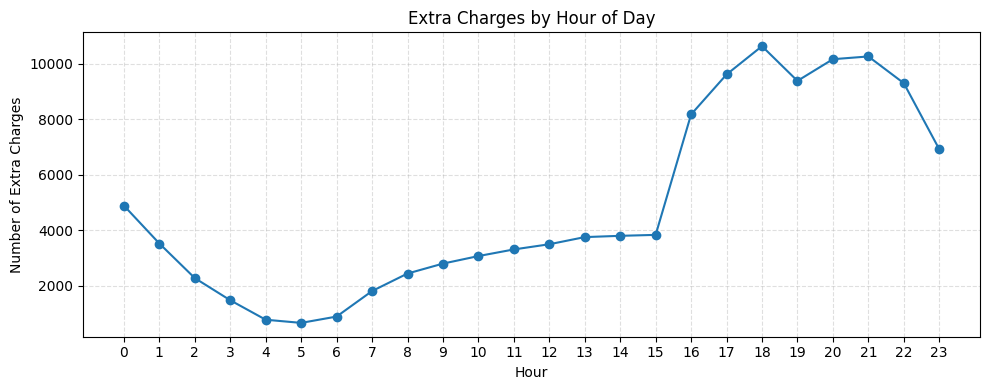

In [ ]:
#When extras occur the most by hour
extras_by_hour = extra_data.groupby('pickup_hour').size()
plt.figure(figsize=(10,4))
plt.plot(extras_by_hour.index, extras_by_hour.values, marker='o')
plt.title("Extra Charges by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Extra Charges")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



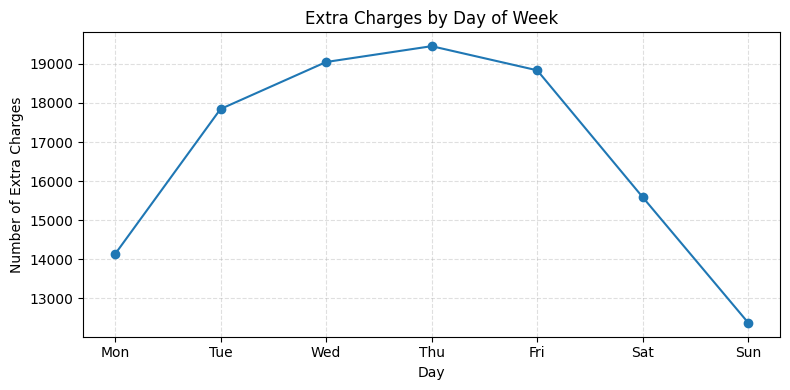

In [ ]:
extras_by_dow = extra_data.groupby('day_of_week').size()
plt.figure(figsize=(8,4))
plt.plot(extras_by_dow.index, extras_by_dow.values, marker='o')
plt.title("Extra Charges by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Extra Charges")
plt.xticks(range(7), dow_labels)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

NYC taxi demand shows strong temporal patterns with clear hourly, weekday/weekend, and seasonal fluctuations.

1. Temporal Demand Patterns

    11 AM – 7 PM is the busiest period.

    Over 12,000 scaled trips per hour occur during these hours.

    Indicates a strong midday movement window for both routine and leisure travel.

2. Fare Dynamics

    Average fare per mile is highest during peak midday hours.

    Customers already expect premium pricing at this time.

    Helps justify dynamic or surge-based pricing models.

3. Vendor-Level Pricing Issues

    Vendor 1 is applying incorrect pricing patterns.

    They increase prices at night, even though demand actually drops.

    Indicates a need for recalibration of pricing rules.

4. Spatial Demand Trends

    Consistent high-demand pickup and dropoff zones identified.

    Nighttime hotspots differ from daytime patterns.

    Supports time-aware zone-based cab deployment.

5. Route & Congestion Insights

    Slow-route analysis shows recurring bottlenecks on certain PU–DO combinations.

    Issues are most severe during evening congestion hours.

    Useful for route optimization & dispatch recommendations.

6. Passenger Count Behavior

    Multi-passenger trips peak at certain times of day.

    Opportunity to optimize shared rides / pooling strategies.

7. Extra Charges Misalignment

    Rush-hour extras & overnight charges do not align with actual demand window.

    Significant scope to update surcharge timing for better revenue and fairness.

Overall Insight

    There is strong potential to improve taxi deployment, dynamic pricing, and routing using data-driven strategies based on actual temporal, spatial, and passenger behavior patterns.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Routing Optimization Based on Speed & Congestion

    Use the slowest routes per hour to reroute taxis away from highly congested roads during peak times.

    Identify bottleneck hours (e.g., evening congestion window) where average route speeds drop significantly.

    Recommend alternative corridors for drivers to avoid predictable choke points.

    Provide hour-by-hour optimal route advisories based on historical speed + pickup density patterns.

Dispatch Optimization Based on Hourly Demand

    Increase dispatch density 11 AM – 7 PM, the window with:

    Maximum rides

    Highest fare per mile

    Strong willingness-to-pay from customers

    Reduce driver idle time by prioritizing dispatch toward:

    Major pickup clusters (Midtown, airports, Downtown)

    High-demand zones where supply < demand

    Use predictable hourly patterns to pre-position drivers 30–45 minutes before demand spikes.

Dynamic Supply Allocation

    Implement continuous repositioning of cabs:

    Move cars from low-ratio (drop-off heavy) zones

    To high-ratio (pickup-heavy) zones

    Target pickup zones where PU/DO ratio > 1.5.

    Examples of consistently high-ratio zones:

    JFK Airport

    East Elmhurst

    East New York

Night-time Dispatch Strategy (11 PM – 5 AM)

    Focus dispatch on night-specific hotspots such as:

    Nightlife areas: East Village, West Village, Lower East Side, Clinton East, Greenwich Village South

    Transit hubs: Penn Station, LaGuardia Airport

    Reduce oversupply in low-demand residential/suburban zones during night hours.

Reduce Inefficiencies Using Speed Data

    Avoid PU–DO pairs identified as chronically slow during evening peaks.

    Encourage route diversification to reduce congestion buildup.

    Use ETA-based intelligent dispatching to match drivers to trips where they can complete rides fastest.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

- Zone-Based Deployment Strategy
Position higher number of taxis in top 10 pickup zones (identified earlier) during:
11 AM–7 PM (high volume)
Saturday, Wednesday, Thursday (top demand days)


- Stations with consistently high dropoffs but lower pickups need pull-in support:
Example: Bring taxis into the zone after large influxes (e.g., events, dining districts).


- Weekend vs Weekday Positioning
Weekdays: Focus on business districts (Midtown, Financial District) during 8 AM–11 AM and 4 PM–7 PM.
Weekends: Prioritize nightlife areas (Lower Manhattan, Brooklyn hotspots) from 9 PM–2 AM.


- Night-time Strategic Placement
Use the top 10 night pickup zones to place more taxis after 11 PM:
These zones show disproportionately high night activity and can reduce empty mileage.

- Passenger Count Zones
Zones with high average passengers (e.g., tourist areas, hotel regions) should receive:
Larger vehicles
Shared-ride optimized drivers
Pricing tailored for multi-passenger rides


- Balancing Pickup/Dropoff Ratios
For high pickup/dropoff zones:
Maintain high taxi density to avoid unmet demand.


- For low pickup/high dropoff zones:
Deploy automated repositioning alerts to avoid empty return trips.


- Event-Based Micro-Zoning
Periodically analyze zones with high extras/rush-hour charges:
These often correlate with stadium events, concerts, parades, or sudden traffic surges.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Time-Based Pricing

    Increase fares between 11 AM–7 PM, with a stronger premium at 3 PM.

    These hours align with:

    Highest trip volume

    Highest fare-per-mile

    Strong customer willingness-to-pay

    Midday premium pricing will increase revenue while staying acceptable to riders.

Vendor-Level Adjustments

    Vendor 1 should:

    Increase prices during 11 AM–7 PM to match true demand.

    Reduce unnecessary price hikes after 8 PM, which currently do not reflect customer traffic.

    This correction aligns Vendor 1’s pricing curve with actual behavior, improving both market share and revenue.

Day-of-Week Pricing

    Saturday shows high pickup volume but fare-per-mile is relatively low.
    → Introduce Saturday premium pricing.

    Wednesday/Thursday also show notable demand.
    → Apply moderate surcharges to match weekday flow.

Distance-Tiered Pricing

    Short Trips (0–2 miles)

    Highest congestion & highest operational cost.

    Add minor surcharge: + $0.50

    Medium Trips (2–5 miles)

    Keep base pricing unchanged.

    Long Trips (>5 miles)

    Offer slight discount during low-demand hours to encourage drivers to accept long routes.

    Helps remain competitive vs. Vendor 2.

Night Pricing Adjustments

    Reduce night premium after 12 AM, unless:

    Trip originates from top 10 nightlife hotspots, or

    Data shows sustained high demand (weekends, special events).

    Prevents unfair overpricing while preserving revenue in active zones.

Surcharge Optimization

    Current rush-hour fees are not aligned with real congestion.
    Move the surcharge window to 11 AM–7 PM, since this period has:

    Highest ride volume

    Highest fare-per-mile

    Highest congestion indicators
    This ensures surcharges reflect actual operational strain.

Tip-Driven Incentives

    Tipping analysis shows highest tips for:

    Shorter rides

    Trips with 5–6 passengers

    Late evening trips (6 PM–7 PM)

    Encourage drivers to accept these trip types through:

    Micro-bonuses

    Route preference

    Priority dispatching